# Pipeline Hierárquico de Classificação de Espécies Intertidais 
**Autora:** Catarina Dias de Almeida Abrantes (202306408)
**Supervisão:** Fernando P. Lima
**Instituição:** FCUP / CIBIO-BIOPOLIS, 2026

Pipeline hierárquico a dois níveis baseado em EfficientNet-B0 para classificação
de 17 espécies intertidais em 6 grupos biológicos. Os crops já foram extraídos
e guardados no dataset `estagio-crops-v5n` — as secções 2, 3 e 4 estão
desativadas e servem apenas de documentação do processo de preparação dos dados.

## 1. Imports e caminhos

In [2]:
import os, json, cv2, numpy as np, random, shutil, subprocess
from tqdm import tqdm
from collections import defaultdict
from scipy import stats
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, balanced_accuracy_score,
    cohen_kappa_score, matthews_corrcoef,
    roc_auc_score, recall_score
)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image

random.seed(42); np.random.seed(42); torch.manual_seed(42)
print("Imports OK")

BASE_INPUT = "/kaggle/input/datasets/catarinaabrantes/estagio-intertidal"
DATASETS = [
    (f"{BASE_INPUT}/Estagios FCUP",                    "FCUP"),
    (f"{BASE_INPUT}/Estagios FCUP - from BIOINTERACT", "BIOINTERACT"),
    (f"{BASE_INPUT}/Fixed quadrats PT 2",              "FI")
]

CROPS_INPUT         = "/kaggle/input/datasets/catarinaabrantes/estagio-crops-v5l"
BASE_CROPS_TRAIN    = f"{CROPS_INPUT}/train"
BASE_CROPS_VAL      = f"{CROPS_INPUT}/val"
BASE_CROPS_TEST     = f"{CROPS_INPUT}/test"
BASE_CROPS_TEST_BAL = f"{CROPS_INPUT}/test_bal"
BASE_CROPS_UNK      = f"{CROPS_INPUT}/unknown"
SPLIT_JSON          = f"{CROPS_INPUT}/foto_split_v5l.json"

# Carregar fotos_por_classe e foto_split_map do split guardado
with open(SPLIT_JSON) as f:
    split_data = json.load(f)
foto_split_map   = split_data["foto_split_map"]
fotos_por_classe = defaultdict(dict)
for cls, fotos in split_data["fotos_por_classe"].items():
    for fk, info in fotos.items():
        fotos_por_classe[cls][fk] = info

min_test = min(
    len(os.listdir(os.path.join(BASE_CROPS_TEST_BAL, c)))
    for c in os.listdir(BASE_CROPS_TEST_BAL)
    if os.path.isdir(os.path.join(BASE_CROPS_TEST_BAL, c))
)
print(f"Crops carregados do v5n. Mínimo crops teste: {min_test}")

MAX_CROPS_POR_FOTO  = 15    # cap por fotografia — controla desequilíbrio sem descartar dados
# Sem cap por classe no treino — o cap por fotografia é suficiente
SPLIT_RATIOS        = (0.70, 0.15, 0.15)
EARLY_STOP_PATIENCE = 10
BOOTSTRAP_N         = 1000

# Classes com dados insuficientes para avaliação robusta
# Motivo: apenas presentes no dataset FCUP + apenas 6 crops de teste
CLASSES_INSUFICIENTES = ["Actinia_equina", "Filamentosa_vermelha"]

def get_oversample_target(n_crops):
    if n_crops < 50:  return 600
    if n_crops < 100: return 400
    if n_crops < 200: return 200
    return None

GRUPOS = {
    "algas_vermelhas": [
        "Osmundea_pinnatifida", "Mastocarpus_stellatus",
        "Porphyra_umbilicalis", "Filamentosa_vermelha"
    ],
    "algas_castanhas": ["Fucus_spp", "Ascophyllum_nudosum"],
    "algas_verdes":    ["Ulva_spp"],
    "cracas":          ["Cracas", "Austrominius_modestus"],
    "moluscos":        ["Patella", "Mytilus", "Littorina", "Phorcus_sp",
                        "Gibbula_umbilicalis", "Nucella_lapilus"],
    "outros_animais":  ["Actinia_equina", "Sabellaria_alveolata"]
}

FUSOES = {
    # fusões originais
    "fucus":             "Fucus_spp",
    "FUCUS":             "Fucus_spp",
    "Ulva":              "Ulva_spp",
    "Ulva_intestinalis": "Ulva_spp",
    "Ulvophyceae":       "Ulva_spp",

    # Fixed quadrats PT 2 — nomes com espaços e pontuação diferente
    "Actinia equina":            "Actinia_equina",
    "Chthamalus spp._Cracas":    "Cracas",
    "Filamentosa vermelha":      "Filamentosa_vermelha",
    "Fucus spp.":                "Fucus_spp",
    "Gibbula umbilicalis":       "Gibbula_umbilicalis",
    "Mastocarpus stellatus":     "Mastocarpus_stellatus",
    "Mytilus galloprovincialis": "Mytilus",
    "Nucella lapilus":           "Nucella_lapilus",
    "Osmundea pinnatifida":      "Osmundea_pinnatifida",
    "Patella spp.":              "Patella",
    "Phorcus sp.":               "Phorcus_sp",
    "Porphyra umbilicalis":      "Porphyra_umbilicalis",
    "Sabellaria alveolata":      "Sabellaria_alveolata",
    "Ulva spp.":                 "Ulva_spp",
    # ignorados: Fixed-quadrats-L1EL, Colour plate, Logger, Screws, Washer
}

TODAS_CLASSES = [esp for grupo in GRUPOS.values() for esp in grupo]

CLASSES_UNKNOWN = [
    "Chondracantus_acicularis", "Catenella_caespitosa",
    "Caulacanthus_ustulatus",   "Fucus_vesiculosus",
    "Chondrus_crispus",         "Hildenbrandia", "chthamallus",
]

grupo_cores = {
    "algas_vermelhas": "#e74c3c",
    "algas_castanhas": "#8B4513",
    "algas_verdes":    "#27ae60",
    "cracas":          "#f39c12",
    "moluscos":        "#2980b9",
    "outros_animais":  "#8e44ad",
}
especie_para_grupo = {esp: grupo for grupo, especies in GRUPOS.items() for esp in especies}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)
print(f"\nClasses do modelo: {len(TODAS_CLASSES)}")
for grupo, especies in GRUPOS.items():
    print(f"  {grupo}: {especies}")
print(f"\nClasses com dados insuficientes (excluídas da análise robusta):")
for cls in CLASSES_INSUFICIENTES:
    print(f"  {cls}")

Imports OK
Crops carregados do v5n. Mínimo crops teste: 8
Dispositivo: cuda

Classes do modelo: 17
  algas_vermelhas: ['Osmundea_pinnatifida', 'Mastocarpus_stellatus', 'Porphyra_umbilicalis', 'Filamentosa_vermelha']
  algas_castanhas: ['Fucus_spp', 'Ascophyllum_nudosum']
  algas_verdes: ['Ulva_spp']
  cracas: ['Cracas', 'Austrominius_modestus']
  moluscos: ['Patella', 'Mytilus', 'Littorina', 'Phorcus_sp', 'Gibbula_umbilicalis', 'Nucella_lapilus']
  outros_animais: ['Actinia_equina', 'Sabellaria_alveolata']

Classes com dados insuficientes (excluídas da análise robusta):
  Actinia_equina
  Filamentosa_vermelha


## 2. Split por fotografia (70/15/15)

O split é feito ao nível da **fotografia** (não do crop individual) para evitar data leakage: todos os crops de uma mesma fotografia ficam no mesmo conjunto (treino, validação ou teste).

> ⚠️ Secção desativada — split já calculado e guardado em `estagio-crops-v5n/foto_split_v5l.json`, carregado na secção 1.

In [3]:
def get_classe_final(nome_raw):
    # Primeiro tenta o nome original (para Fixed quadrats PT 2 com espaços)
    if nome_raw in FUSOES:
        return FUSOES[nome_raw]
    # Depois tenta normalizado (substitui espaços por _ e remove pontos)
    nome = nome_raw.replace(" ", "_").replace(".", "")
    return FUSOES.get(nome, nome)

def fazer_split_por_fotografia(ratios=(0.70, 0.15, 0.15)):
    fotos_por_classe = defaultdict(dict)

    for dataset_path, dataset_tag in DATASETS:
        for split in ["train","valid","val","test"]:
            ann_file = os.path.join(dataset_path, split, "_annotations.coco.json")
            if not os.path.exists(ann_file): continue
            with open(ann_file) as f:
                coco = json.load(f)
            images     = {img["id"]: img for img in coco["images"]}
            categories = {cat["id"]: cat["name"] for cat in coco["categories"]}
            anns_per_image = defaultdict(list)
            for ann in coco["annotations"]:
                anns_per_image[ann["image_id"]].append(ann)

            for image_id, anns in anns_per_image.items():
                foto_key = f"{dataset_tag}_{split}_{image_id}"
                img_info = images[image_id]
                for ann in anns:
                    cls_raw   = categories[ann["category_id"]]
                    cls_final = get_classe_final(cls_raw)
                    if cls_final in TODAS_CLASSES:
                        if foto_key not in fotos_por_classe[cls_final]:
                            fotos_por_classe[cls_final][foto_key] = {
                                "dataset_path": dataset_path, "split": split,
                                "image_id": image_id, "file_name": img_info["file_name"],
                                "dataset_tag": dataset_tag,
                            }
                    elif cls_final in CLASSES_UNKNOWN:
                        unk_key = f"__unk__{cls_final}"
                        if foto_key not in fotos_por_classe[unk_key]:
                            fotos_por_classe[unk_key][foto_key] = {
                                "dataset_path": dataset_path, "split": split,
                                "image_id": image_id, "file_name": img_info["file_name"],
                                "dataset_tag": dataset_tag,
                            }

    foto_split_map = {}
    print("Fotografias por classe e split:")
    for cls in TODAS_CLASSES:
        fotos = list(fotos_por_classe[cls].keys())
        random.shuffle(fotos)
        n = len(fotos)
        n_test = max(1, int(n * ratios[2]))
        n_val  = max(1, int(n * ratios[1]))
        for fk in fotos[:n_test]:
            foto_split_map.setdefault(fk, {})[cls] = "test"
        for fk in fotos[n_test:n_test+n_val]:
            foto_split_map.setdefault(fk, {})[cls] = "val"
        for fk in fotos[n_test+n_val:]:
            foto_split_map.setdefault(fk, {})[cls] = "train"
        print(f"  {cls:<35} total={n:>4} | train={n-n_test-n_val:>4} val={n_val:>3} test={n_test:>3}")

    for cls_unk in CLASSES_UNKNOWN:
        for fk in fotos_por_classe.get(f"__unk__{cls_unk}", {}):
            foto_split_map.setdefault(fk, {})[cls_unk] = "unknown"

    with open(SPLIT_JSON, "w") as f:
        json.dump({"foto_split_map": foto_split_map,
                   "fotos_por_classe": {
                       k: {fk: {kk: str(vv) for kk, vv in v.items()}
                           for fk, v in fd.items()}
                       for k, fd in fotos_por_classe.items()}}, f)
    print(f"\nSplit guardado em {SPLIT_JSON}")
    return fotos_por_classe, foto_split_map

## 3. Extrair crops com cap por fotografia

Cada anotação COCO é recortada da fotografia original e guardada como imagem independente. O cap de **15 crops por fotografia** evita que fotografias com muitas anotações dominem o dataset sem descartar dados úteis de fotografias mais pequenas.

> ⚠️ Secção desativada — crops já extraídos e guardados em `estagio-crops-v5n`.

In [4]:
def extrair_crops(fotos_por_classe, foto_split_map, max_crops_por_foto=15):
    for pasta in [BASE_CROPS_TRAIN, BASE_CROPS_VAL, BASE_CROPS_TEST, BASE_CROPS_UNK]:
        if os.path.exists(pasta): shutil.rmtree(pasta)
        os.makedirs(pasta, exist_ok=True)

    contagens = defaultdict(lambda: defaultdict(int))

    for cls in TODAS_CLASSES:
        for foto_key, info in tqdm(fotos_por_classe[cls].items(),
                                   desc=f"Crops {cls}", leave=False):
            split_desta_foto = foto_split_map.get(foto_key, {}).get(cls, "train")
            pasta_split = {"train": BASE_CROPS_TRAIN,
                           "val":   BASE_CROPS_VAL,
                           "test":  BASE_CROPS_TEST}[split_desta_foto]

            img_path = os.path.join(info["dataset_path"], info["split"], info["file_name"])
            if not os.path.exists(img_path): continue
            image = cv2.imread(img_path)
            if image is None: continue

            ann_file = os.path.join(info["dataset_path"], info["split"],
                                    "_annotations.coco.json")
            with open(ann_file) as f:
                coco = json.load(f)
            categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

            anns_cls = [ann for ann in coco["annotations"]
                        if ann["image_id"] == info["image_id"]
                        and get_classe_final(categories[ann["category_id"]]) == cls]

            if len(anns_cls) > max_crops_por_foto:
                anns_cls = random.sample(anns_cls, max_crops_por_foto)

            for ann in anns_cls:
                x,y,w,h = map(int, ann["bbox"])
                H,W = image.shape[:2]
                x,y = max(0,x), max(0,y)
                w,h = min(w,W-x), min(h,H-y)
                if w < 10 or h < 10: continue
                crop = image[y:y+h, x:x+w]
                if crop.size == 0: continue
                dest_dir = os.path.join(pasta_split, cls)
                os.makedirs(dest_dir, exist_ok=True)
                fname = f"{info['dataset_tag']}_{info['split']}_{info['image_id']}_{ann['id']}.jpg"
                cv2.imwrite(os.path.join(dest_dir, fname), crop)
                contagens[cls][split_desta_foto] += 1

    for cls_unk in CLASSES_UNKNOWN:
        for foto_key, info in tqdm(fotos_por_classe.get(f"__unk__{cls_unk}", {}).items(),
                                   desc=f"Unknown {cls_unk}", leave=False):
            img_path = os.path.join(info["dataset_path"], info["split"], info["file_name"])
            if not os.path.exists(img_path): continue
            image = cv2.imread(img_path)
            if image is None: continue
            ann_file = os.path.join(info["dataset_path"], info["split"],
                                    "_annotations.coco.json")
            with open(ann_file) as f:
                coco = json.load(f)
            categories = {cat["id"]: cat["name"] for cat in coco["categories"]}
            anns_cls = [ann for ann in coco["annotations"]
                        if ann["image_id"] == info["image_id"]
                        and get_classe_final(categories[ann["category_id"]]) == cls_unk]
            if len(anns_cls) > max_crops_por_foto:
                anns_cls = random.sample(anns_cls, max_crops_por_foto)
            for ann in anns_cls:
                x,y,w,h = map(int, ann["bbox"])
                H,W = image.shape[:2]
                x,y = max(0,x), max(0,y)
                w,h = min(w,W-x), min(h,H-y)
                if w < 10 or h < 10: continue
                crop = image[y:y+h, x:x+w]
                if crop.size == 0: continue
                dest_dir = os.path.join(BASE_CROPS_UNK, cls_unk)
                os.makedirs(dest_dir, exist_ok=True)
                fname = f"{info['dataset_tag']}_{info['split']}_{info['image_id']}_{ann['id']}.jpg"
                cv2.imwrite(os.path.join(dest_dir, fname), crop)
                contagens[cls_unk]["unknown"] += 1

    print(f"\nCrops extraídos (cap={max_crops_por_foto} por fotografia, sem cap por classe):")
    print(f"{'Classe':<35} {'Train':>7} {'Val':>6} {'Test':>6}")
    print("-"*55)
    for cls in TODAS_CLASSES:
        tr = contagens[cls].get("train", 0)
        v  = contagens[cls].get("val",   0)
        te = contagens[cls].get("test",  0)
        print(f"{cls:<35} {tr:>7} {v:>6} {te:>6}")
    return contagens

# contagens = extrair_crops(fotos_por_classe, foto_split_map, MAX_CROPS_POR_FOTO)
# print("\nExtracção concluída.")

## 4. Criar conjunto de teste balanceado

Para avaliação final do pipeline é criado um subconjunto de teste com o mesmo número de crops por classe (limitado pela classe com menos amostras). O treino e a validação mantêm todos os crops disponíveis.

> ⚠️ Secção desativada — `test_bal` já existe no dataset `estagio-crops-v5n`.

In [5]:
# Criar teste balanceado para avaliação final do pipeline
n_test_por_classe = {}
for cls in TODAS_CLASSES:
    p = os.path.join(BASE_CROPS_TEST, cls)
    n_test_por_classe[cls] = len(os.listdir(p)) if os.path.exists(p) else 0

min_test = min(n_test_por_classe.values())
print(f"Mínimo crops de teste por classe: {min_test}")
print(f"Limitado por: {[cls for cls,n in n_test_por_classe.items() if n == min_test]}")
print(f"Teste balanceado final: {min_test} × {len(TODAS_CLASSES)} = {min_test*len(TODAS_CLASSES)} crops")

# test_bal já existe no dataset estagio-crops-v5n — não recriar (filesystem read-only)
# if os.path.exists(BASE_CROPS_TEST_BAL): shutil.rmtree(BASE_CROPS_TEST_BAL)
# os.makedirs(BASE_CROPS_TEST_BAL, exist_ok=True)
# for cls in TODAS_CLASSES:
#     src = os.path.join(BASE_CROPS_TEST, cls)
#     if not os.path.exists(src): continue
#     dst = os.path.join(BASE_CROPS_TEST_BAL, cls)
#     os.makedirs(dst, exist_ok=True)
#     imgs = os.listdir(src)
#     for img in random.sample(imgs, min(min_test, len(imgs))):
#         shutil.copy(os.path.join(src, img), os.path.join(dst, img))

print("\nCrops finais:")
for split, pasta in [("train (sem cap entre classes)", BASE_CROPS_TRAIN),
                     ("val (sem cap entre classes)",   BASE_CROPS_VAL),
                     ("test (desequilibrado)",          BASE_CROPS_TEST),
                     ("test_bal (balanceado)",          BASE_CROPS_TEST_BAL),
                     ("unknown",                        BASE_CROPS_UNK)]:
    total = sum(len(os.listdir(os.path.join(pasta, cls)))
                for cls in os.listdir(pasta)
                if os.path.isdir(os.path.join(pasta, cls)))
    print(f"  {split}: {total} crops")

print("\nCrops de treino por classe:")
for cls in sorted(os.listdir(BASE_CROPS_TRAIN)):
    p = os.path.join(BASE_CROPS_TRAIN, cls)
    if os.path.isdir(p):
        print(f"  {cls}: {len(os.listdir(p))}")

Mínimo crops de teste por classe: 8
Limitado por: ['Littorina']
Teste balanceado final: 8 × 17 = 136 crops

Crops finais:
  train (sem cap entre classes): 17971 crops
  val (sem cap entre classes): 3765 crops
  test (desequilibrado): 3669 crops
  test_bal (balanceado): 136 crops
  unknown: 394 crops

Crops de treino por classe:
  Actinia_equina: 52
  Ascophyllum_nudosum: 244
  Austrominius_modestus: 200
  Cracas: 6363
  Filamentosa_vermelha: 84
  Fucus_spp: 544
  Gibbula_umbilicalis: 764
  Littorina: 59
  Mastocarpus_stellatus: 126
  Mytilus: 3223
  Nucella_lapilus: 134
  Osmundea_pinnatifida: 145
  Patella: 4177
  Phorcus_sp: 609
  Porphyra_umbilicalis: 199
  Sabellaria_alveolata: 362
  Ulva_spp: 686


## 4b. Guardar crops no Kaggle

> ⚠️ Secção desativada — crops já publicados em `estagio-crops-v5n`.

In [ ]:
os.makedirs(OUT_CROPS, exist_ok=True)
for split, pasta in [
    ("train",    BASE_CROPS_TRAIN),
    ("val",      BASE_CROPS_VAL),
    ("test",     BASE_CROPS_TEST),
    ("test_bal", BASE_CROPS_TEST_BAL),
    ("unknown",  BASE_CROPS_UNK),
]:
    dst = os.path.join(OUT_CROPS, split)
    if os.path.exists(pasta):
        shutil.copytree(pasta, dst)
        n = sum(len(os.listdir(os.path.join(dst, c)))
                for c in os.listdir(dst) if os.path.isdir(os.path.join(dst, c)))
        print(f"Copiado: {split} ({n} crops)")
shutil.copy(SPLIT_JSON, OUT_CROPS)
with open(os.path.join(OUT_CROPS, "dataset-metadata.json"), "w") as f:
    json.dump({"title": "estagio-crops-v5n",
               "id":    "catarinaabrantes/estagio-crops-v5n",
               "licenses": [{"name": "CC0-1.0"}]}, f)
r = subprocess.run(["kaggle", "datasets", "create", "-p", OUT_CROPS, "--dir-mode", "zip"],
                   capture_output=True, text=True)
print(r.stdout)
print("\n✅ Crops guardados em estagio-crops-v5n!")


## 5. Transformações e data augmentation

Definidas três estratégias de transformação:
- **Normal** — augmentation moderada, usada nos crops originais de treino
- **Agressiva** — augmentation forte (perspective, grayscale, erasing alargado), usada nos crops replicados por oversampling
- **TTA** — 5 passes de inferência (original, flip horizontal, flip vertical, crop central, rotação 90°) cujas probabilidades são depois calculadas em média

O dataset de treino usa **oversampling adaptativo por classe**: classes com menos de 50 crops são replicadas até 600; entre 50–100 até 400; entre 100–200 até 200.

In [6]:
train_transforms_normal = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(360),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

train_transforms_aggressive = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(360),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.15),
    transforms.RandomGrayscale(p=0.15),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 3.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

tta_transforms = [
    transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomVerticalFlip(p=1.0),
                        transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((256,256)), transforms.CenterCrop(224),
                        transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((224,224)), transforms.RandomRotation(degrees=(90,90)),
                        transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]

val_test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class OversampledDataset(Dataset):
    def __init__(self, train_dir):
        self.samples = []
        class_names = sorted(os.listdir(train_dir))
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.classes = class_names
        print("  Oversample adaptativo:")
        for cls in class_names:
            cls_path = os.path.join(train_dir, cls)
            if not os.path.isdir(cls_path): continue
            imgs = [os.path.join(cls_path, f) for f in os.listdir(cls_path)]
            n = len(imgs); idx = self.class_to_idx[cls]
            for img_path in imgs:
                self.samples.append((img_path, idx, False))
            target = get_oversample_target(n)
            if target and n < target:
                extra = random.choices(imgs, k=target - n)
                for img_path in extra:
                    self.samples.append((img_path, idx, True))
                print(f"    {cls:<35} {n:>5} → {target} (+{target-n})")
            else:
                print(f"    {cls:<35} {n:>5} (sem oversample)")
        random.shuffle(self.samples)
        print(f"\n  Total: {len(self.samples)} amostras")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, class_idx, aggressive = self.samples[idx]
        image = Image.open(path).convert("RGB")
        t = train_transforms_aggressive if aggressive else train_transforms_normal
        return t(image), class_idx

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1-lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

print("Transformações OK")

Transformações OK


## 6. Focal Loss, scheduler e funções de treino

Componentes do pipeline de treino:
- **FocalLoss (γ=0,5)** — usada nos especialistas de nível 2; reduz o peso dos exemplos fáceis e foca o treino nos difíceis
- **CrossEntropyLoss** — usada no classificador de nível 1 (Focal Loss penalizava a classe Cracas e causava instabilidade)
- **CosineAnnealingWarmRestarts** — scheduler de learning rate com reinícios periódicos
- **Early stopping** por val_acc com patience configurável
- **Mixup** apenas na fase 2 (full fine-tuning), não na fase 1 (backbone congelado)
- **Gradient clipping** max_norm=1,0 — previne explosão de gradientes

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.reduction = reduction
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt      = torch.exp(-ce_loss)
        focal   = (1-pt)**self.gamma * ce_loss
        if self.reduction == "mean": return focal.mean()
        if self.reduction == "sum":  return focal.sum()
        return focal

def train_one_epoch_mixup(model, loader, criterion, optimizer, device,
                           use_mixup=True, alpha=0.2):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="Treino", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        if use_mixup:
            imgs_mix, y_a, y_b, lam = mixup_data(imgs, labels, alpha)
            out  = model(imgs_mix)
            loss = mixup_criterion(criterion, out, y_a, y_b, lam)
        else:
            out  = model(imgs)
            loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum += loss.item()*imgs.size(0)
        correct += (out.argmax(1)==labels).sum().item(); total += labels.size(0)
    return loss_sum/total, correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Avaliação", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs); loss = criterion(out, labels)
            loss_sum += loss.item()*imgs.size(0)
            probs = F.softmax(out, dim=1); preds = out.argmax(1)
            correct += (preds==labels).sum().item(); total += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return loss_sum/total, correct/total, all_labels, all_preds, np.array(all_probs)

def train_model_early_stop(model, train_loader, val_loader, criterion, optimizer,
                            save_path, num_epochs=40, scheduler=None,
                            patience=10, use_mixup=True):
    best_val_acc = 0.0
    epochs_no_improve = 0
    tl_list, vl_list, ta_list, va_list = [], [], [], []
    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        tl, ta = train_one_epoch_mixup(model, train_loader, criterion,
                                        optimizer, device, use_mixup=use_mixup)
        vl, va, _, _, _ = evaluate(model, val_loader, criterion, device)
        if scheduler: scheduler.step()
        tl_list.append(tl); vl_list.append(vl)
        ta_list.append(ta); va_list.append(va)
        print(f"Treino    — Loss: {tl:.4f} | Acc: {ta:.4f}")
        print(f"Validação — Loss: {vl:.4f} | Acc: {va:.4f}")
        if va > best_val_acc:
            best_val_acc = va; epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  → Guardado (val_acc={best_val_acc:.4f})")
        else:
            epochs_no_improve += 1
            print(f"  → Sem melhoria ({epochs_no_improve}/{patience})")
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping na época {epoch+1}."); break
    print(f"\nConcluído. Melhor val_acc: {best_val_acc:.4f}")
    return tl_list, vl_list, ta_list, va_list

def plot_curves(tl, vl, ta, va, title, vline=None):
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
    ep = range(1,len(tl)+1)
    ax1.plot(ep,tl,label="Treino"); ax1.plot(ep,vl,label="Validação")
    if vline: ax1.axvline(x=vline,color="gray",linestyle="--",label="Início fase 2")
    ax1.set_title(f"{title} — Perda"); ax1.set_xlabel("Época"); ax1.legend()
    ax2.plot(ep,ta,label="Treino"); ax2.plot(ep,va,label="Validação")
    if vline: ax2.axvline(x=vline,color="gray",linestyle="--",label="Início fase 2")
    ax2.set_title(f"{title} — Accuracy"); ax2.set_xlabel("Época"); ax2.legend()
    plt.tight_layout(); plt.show()

def build_efficientnet_b0(num_classes, device, freeze_backbone=False):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    if freeze_backbone:
        for p in model.parameters(): p.requires_grad = False
        for p in model.classifier.parameters(): p.requires_grad = True
    return model.to(device)

def bootstrap_ci(labels, preds, n_bootstrap=1000, ci=95):
    scores = []
    n = len(labels)
    la, pa = np.array(labels), np.array(preds)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        scores.append(balanced_accuracy_score(la[idx], pa[idx]))
    return np.mean(scores), np.percentile(scores,(100-ci)/2), np.percentile(scores,100-(100-ci)/2)

def compute_all_metrics(labels, preds, probs, class_names, title, cmap="Purples"):
    bal   = balanced_accuracy_score(labels, preds)
    kappa = cohen_kappa_score(labels, preds)
    mcc   = matthews_corrcoef(labels, preds)
    top2  = np.mean([labels[i] in np.argsort(probs[i])[-2:]
                     for i in range(len(labels))])
    try:
        auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except Exception:
        auc = float("nan")
    mean_bs, lower_bs, upper_bs = bootstrap_ci(labels, preds, BOOTSTRAP_N)

    print(f"\n{'='*65}")
    print(f"{title}")
    print(f"{'='*65}")
    print(f"Balanced Accuracy:    {bal:.4f}")
    print(f"IC 95% (bootstrap):   [{lower_bs:.4f}, {upper_bs:.4f}]")
    print(f"Cohen's Kappa:        {kappa:.4f}")
    print(f"MCC:                  {mcc:.4f}")
    print(f"Top-2 Accuracy:       {top2:.4f}")
    print(f"ROC-AUC (macro):      {auc:.4f}")
    print()
    print(classification_report(labels, preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(22, 10))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=axes[0], xticks_rotation=90, cmap=cmap, colorbar=False)
    axes[0].set_title(f"{title} — Contagens")
    ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
        ax=axes[1], xticks_rotation=90, cmap=cmap, colorbar=False)
    axes[1].set_title(f"{title} — Normalizada")
    plt.tight_layout(); plt.show()

    confusions = [(cm[i,j], class_names[i], class_names[j])
                  for i in range(len(class_names))
                  for j in range(len(class_names)) if i != j and cm[i,j] > 0]
    confusions.sort(reverse=True)
    print("Top-10 confusões:")
    for c, real, pred in confusions[:10]:
        print(f"  {real} → {pred}: {c}")

    return {"bal": bal, "kappa": kappa, "mcc": mcc, "top2": top2, "auc": auc,
            "ci_lower": lower_bs, "ci_upper": upper_bs}

print("Funções de treino OK")

Funções de treino OK


## 7. Treinar classificador de nível 1 (grupos biológicos)

Classifica cada crop num dos 6 grupos biológicos. Treino em duas fases:
1. **Fase 1** — backbone congelado, só o classificador treina (feature extraction, sem Mixup, lr=0,001)
2. **Fase 2** — todos os parâmetros livres (full fine-tuning, com Mixup, lr=1e-4)

Usa **CrossEntropyLoss sem class weights** — durante o desenvolvimento verificou-se que Focal Loss no nível 1 penalizava a classe dominante (Cracas) e causava 68,9% de erros inter-grupo.

Nível 1 train: 17971 imagens
Nível 1 val: 3765 imagens
Nível 1 test: 3669 imagens
Nível 1 test_bal: 136 imagens
  Oversample adaptativo:
    algas_castanhas                       788 (sem oversample)
    algas_verdes                          686 (sem oversample)
    algas_vermelhas                       554 (sem oversample)
    cracas                               6563 (sem oversample)
    moluscos                             8966 (sem oversample)
    outros_animais                        414 (sem oversample)

  Total: 17971 amostras

Grupos (nível 1): ['algas_castanhas', 'algas_verdes', 'algas_vermelhas', 'cracas', 'moluscos', 'outros_animais']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s] 



Fase 1 — feature extraction (sem Mixup, sem class weights, B0)

Época 1/40


Treino    — Loss: 0.8511 | Acc: 0.6771
Validação — Loss: 0.7956 | Acc: 0.6975
  → Guardado (val_acc=0.6975)

Época 2/40


Treino    — Loss: 0.7387 | Acc: 0.7153
Validação — Loss: 0.7747 | Acc: 0.7054
  → Guardado (val_acc=0.7054)

Época 3/40


...

Treino    — Loss: 0.3342 | Acc: 0.6662
Validação — Loss: 0.2187 | Acc: 0.9355
  → Sem melhoria (6/10)

Época 33/40


Treino    — Loss: 0.3258 | Acc: 0.6898
Validação — Loss: 0.2158 | Acc: 0.9328
  → Sem melhoria (7/10)

Época 34/40


Treino    — Loss: 0.2958 | Acc: 0.6835
Validação — Loss: 0.2113 | Acc: 0.9325
  → Sem melhoria (8/10)

Época 35/40


Treino    — Loss: 0.3148 | Acc: 0.6964
Validação — Loss: 0.2058 | Acc: 0.9341
  → Sem melhoria (9/10)

Época 36/40


Treino    — Loss: 0.3251 | Acc: 0.6714
Validação — Loss: 0.2224 | Acc: 0.9323
  → Sem melhoria (10/10)

Early stopping na época 36.

Concluído. Melhor val_acc: 0.9386


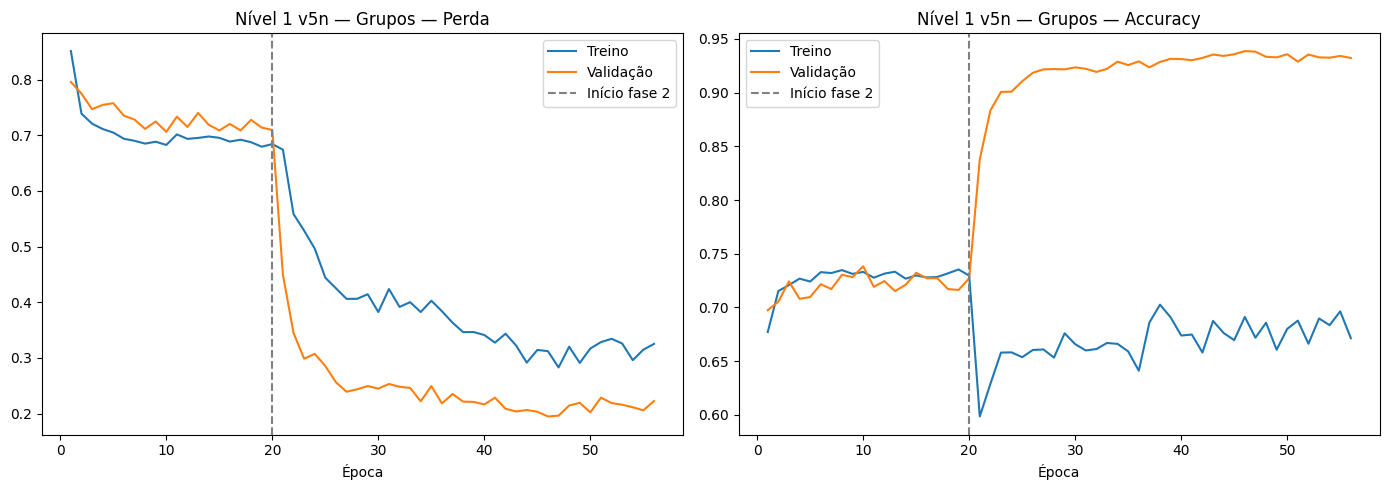


Nível 1 v5n — Grupos
Balanced Accuracy:    0.8854
IC 95% (bootstrap):   [0.8131, 0.9481]
Cohen's Kappa:        0.8762
MCC:                  0.8771
Top-2 Accuracy:       0.9559
ROC-AUC (macro):      0.9855

                 precision    recall  f1-score   support

algas_castanhas       0.88      0.94      0.91        16
   algas_verdes       0.86      0.75      0.80         8
algas_vermelhas       0.97      0.88      0.92        32
         cracas       0.83      0.94      0.88        16
       moluscos       0.88      0.94      0.91        48
 outros_animais       1.00      0.88      0.93        16

       accuracy                           0.90       136
      macro avg       0.90      0.89      0.89       136
   weighted avg       0.91      0.90      0.90       136



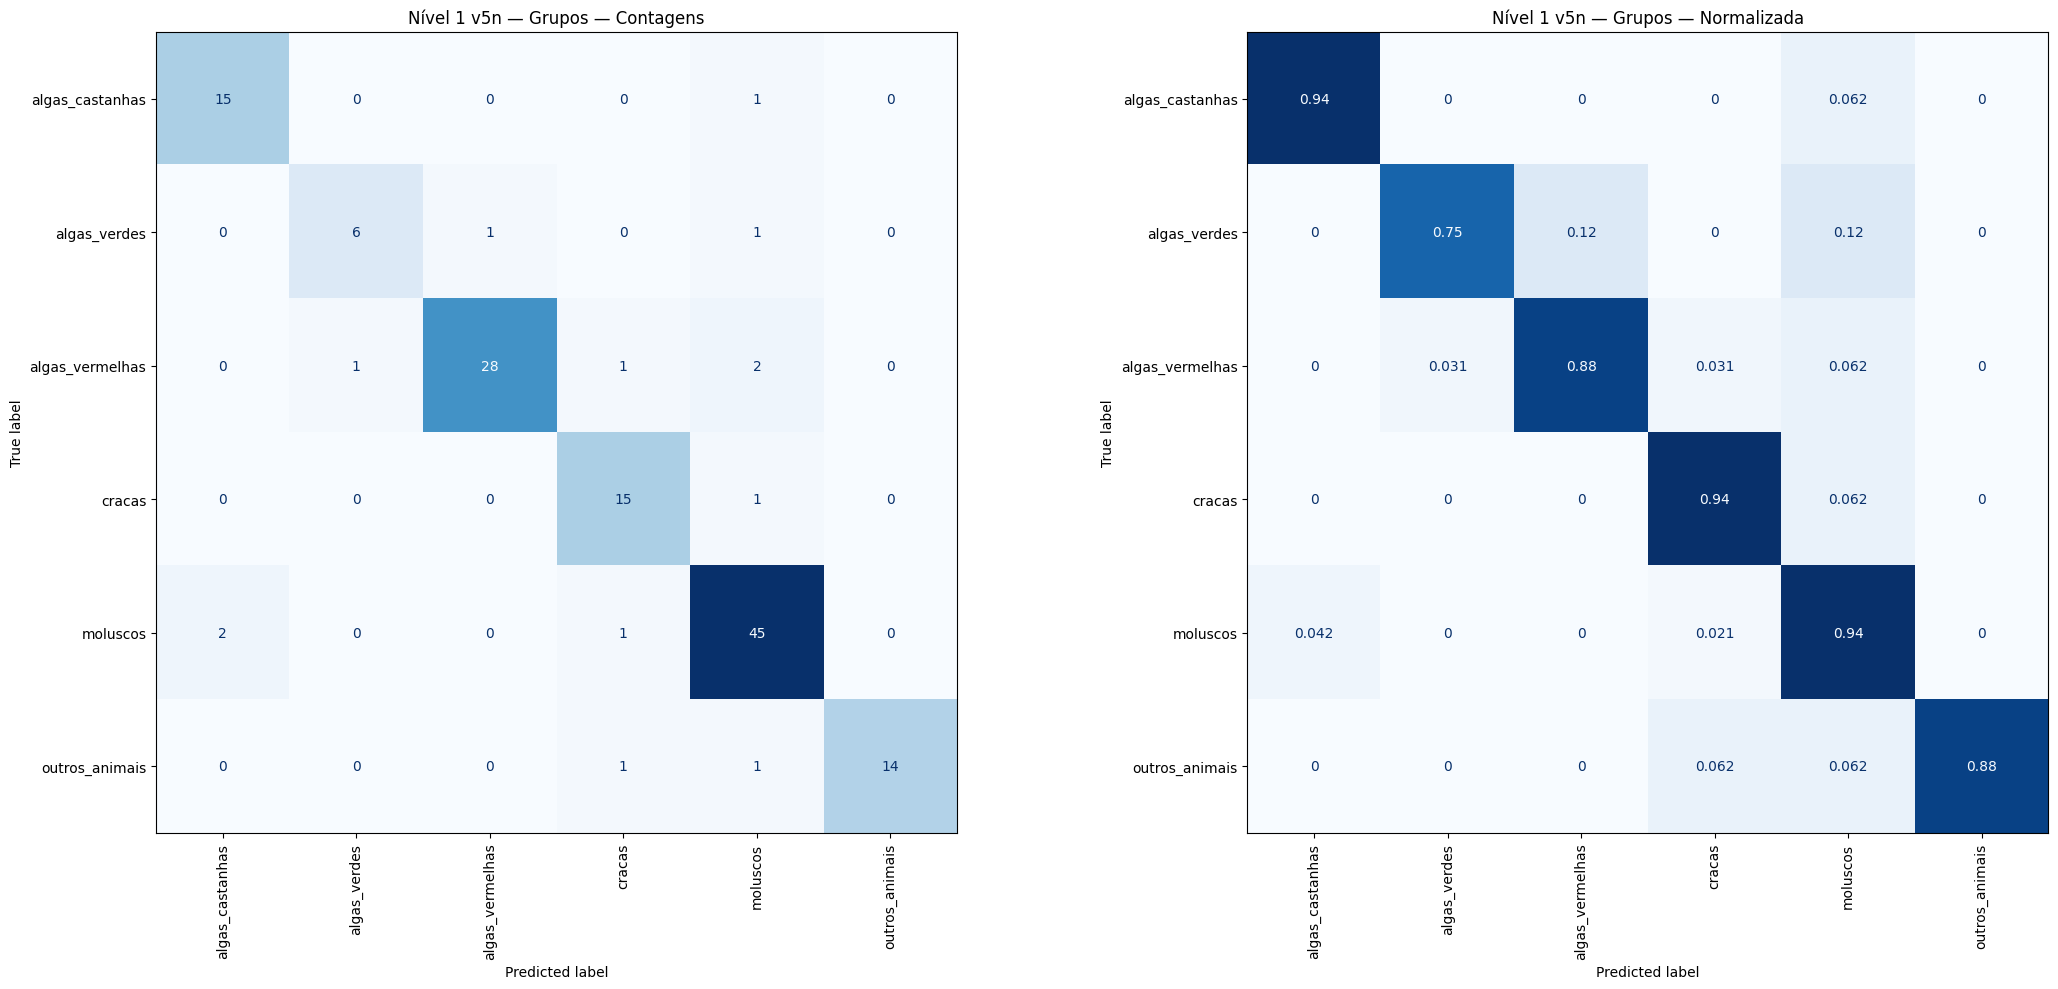

Top-10 confusões:
  moluscos → algas_castanhas: 2
  algas_vermelhas → moluscos: 2
  outros_animais → moluscos: 1
  outros_animais → cracas: 1
  moluscos → cracas: 1
  cracas → moluscos: 1
  algas_vermelhas → cracas: 1
  algas_vermelhas → algas_verdes: 1
  algas_verdes → moluscos: 1
  algas_verdes → algas_vermelhas: 1


In [8]:
LEVEL1_TRAIN    = "/kaggle/working/level1/train"
LEVEL1_VAL      = "/kaggle/working/level1/val"
LEVEL1_TEST     = "/kaggle/working/level1/test"
LEVEL1_TEST_BAL = "/kaggle/working/level1/test_bal"

especie_para_grupo_map = {esp: grupo for grupo, especies in GRUPOS.items()
                           for esp in especies}

for split, pasta_src, pasta_dst in [
    ("train",    BASE_CROPS_TRAIN,    LEVEL1_TRAIN),
    ("val",      BASE_CROPS_VAL,      LEVEL1_VAL),
    ("test",     BASE_CROPS_TEST,     LEVEL1_TEST),
    ("test_bal", BASE_CROPS_TEST_BAL, LEVEL1_TEST_BAL),
]:
    if os.path.exists(pasta_dst): shutil.rmtree(pasta_dst)
    os.makedirs(pasta_dst, exist_ok=True)
    for grupo in GRUPOS:
        os.makedirs(os.path.join(pasta_dst, grupo), exist_ok=True)
    for esp, grupo in especie_para_grupo_map.items():
        src = os.path.join(pasta_src, esp)
        if not os.path.exists(src): continue
        dst = os.path.join(pasta_dst, grupo)
        for img in os.listdir(src):
            shutil.copy(os.path.join(src, img), os.path.join(dst, f"{esp}_{img}"))
    total = sum(len(os.listdir(os.path.join(pasta_dst, g)))
                for g in os.listdir(pasta_dst)
                if os.path.isdir(os.path.join(pasta_dst, g)))
    print(f"Nível 1 {split}: {total} imagens")

train_ds_l1 = OversampledDataset(LEVEL1_TRAIN)
val_ds_l1   = datasets.ImageFolder(LEVEL1_VAL,     transform=val_test_transforms)
test_ds_l1  = datasets.ImageFolder(LEVEL1_TEST_BAL, transform=val_test_transforms)

train_l1 = DataLoader(train_ds_l1, batch_size=32, shuffle=True,  num_workers=2)
val_l1   = DataLoader(val_ds_l1,   batch_size=32, shuffle=False, num_workers=2)
test_l1  = DataLoader(test_ds_l1,  batch_size=32, shuffle=False, num_workers=2)

class_names_l1 = train_ds_l1.classes
print(f"\nGrupos (nível 1): {class_names_l1}")

# Nível 1: CrossEntropy sem class weights (como v5j — melhor nível 1, 25.5% erros inter-grupo)
# Focal Loss no L1 penalizava cracas e causava 68.9% erros inter-grupo (v5k)
criterion_l1 = nn.CrossEntropyLoss()

BEST_L1 = "/kaggle/working/best_level1_v5n.pth"

# Fase 1 — feature extraction (sem Mixup — backbone congelado)
model_l1 = build_efficientnet_b0(len(class_names_l1), device, freeze_backbone=True)
opt1 = optim.Adam(model_l1.classifier.parameters(), lr=0.001)
sch1 = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt1, T_0=10, T_mult=2)
print("\nFase 1 — feature extraction (sem Mixup, sem class weights, B0)")
tl1,vl1,ta1,va1 = train_model_early_stop(
    model_l1, train_l1, val_l1, criterion_l1, opt1, BEST_L1,
    num_epochs=40, scheduler=sch1, patience=EARLY_STOP_PATIENCE, use_mixup=False)

model_l1.load_state_dict(torch.load(BEST_L1, map_location=device))
print("✓ Melhor checkpoint fase 1 carregado")

# Fase 2 — full fine-tuning (com Mixup, lr=1e-4)
for p in model_l1.parameters(): p.requires_grad = True
opt2 = optim.Adam(model_l1.parameters(), lr=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt2, T_0=10, T_mult=2)
print("\nFase 2 — full fine-tuning (com Mixup, lr=1e-4)")
tl2,vl2,ta2,va2 = train_model_early_stop(
    model_l1, train_l1, val_l1, criterion_l1, opt2, BEST_L1,
    num_epochs=40, scheduler=sch2, patience=EARLY_STOP_PATIENCE, use_mixup=True)

plot_curves(tl1+tl2, vl1+vl2, ta1+ta2, va1+va2, "Nível 1 v5n — Grupos", vline=len(tl1))

model_l1.load_state_dict(torch.load(BEST_L1, map_location=device))
_, acc_l1, labels_l1, preds_l1, probs_l1 = evaluate(
    model_l1, test_l1, nn.CrossEntropyLoss(), device)
metrics_l1 = compute_all_metrics(
    labels_l1, preds_l1, probs_l1, class_names_l1, "Nível 1 v5n — Grupos", "Blues")

## 8. Treinar especialistas de nível 2 (espécies dentro de cada grupo)

Um modelo EfficientNet-B0 especialista é treinado para cada grupo com mais de uma espécie (5 grupos no total). Cada especialista só vê as espécies do seu grupo.

Usa **Focal Loss γ=0,5 com class weights** inversamente proporcionais ao número de crops — corrige o desequilíbrio dentro de cada grupo. Mesma estratégia de duas fases do nível 1, com patience=15.


ESPECIALISTA: algas_vermelhas (4 espécies)
  train: 554 crops
  val: 114 crops
  test: 135 crops
  Oversample adaptativo:
    Filamentosa_vermelha                   84 → 400 (+316)
    Mastocarpus_stellatus                 126 → 200 (+74)
    Osmundea_pinnatifida                  145 → 200 (+55)
    Porphyra_umbilicalis                  199 → 200 (+1)

  Total: 1000 amostras
  Classes: ['Filamentosa_vermelha', 'Mastocarpus_stellatus', 'Osmundea_pinnatifida', 'Porphyra_umbilicalis']

Época 1/40


Treino    — Loss: 1.0343 | Acc: 0.4240
Validação — Loss: 0.9433 | Acc: 0.4825
  → Guardado (val_acc=0.4825)

Época 2/40


Treino    — Loss: 0.8023 | Acc: 0.5690
Validação — Loss: 0.8667 | Acc: 0.5175
  → Guardado (val_acc=0.5175)

Época 3/40


Treino    — Loss: 0.7277 | Acc: 0.6170
Validação — Loss: 0.8463 | Acc: 0.5614
  → Guardado (val_acc=0.5614)

Época 4/40


Treino    — Loss: 0.6941 | Acc: 0.6630
Validação — Loss: 0.8400 | Acc: 0.5351
  → Sem melhoria (1/15)

Época 5/40


...

Treino    — Loss: 0.3418 | Acc: 0.5820
Validação — Loss: 0.4316 | Acc: 0.8158
  → Sem melhoria (4/15)

Época 37/40


Treino    — Loss: 0.3543 | Acc: 0.5610
Validação — Loss: 0.4444 | Acc: 0.8246
  → Sem melhoria (5/15)

Época 38/40


Treino    — Loss: 0.3180 | Acc: 0.5990
Validação — Loss: 0.3961 | Acc: 0.7807
  → Sem melhoria (6/15)

Época 39/40


Treino    — Loss: 0.4893 | Acc: 0.6240
Validação — Loss: 0.4267 | Acc: 0.8158
  → Sem melhoria (7/15)

Época 40/40


Treino    — Loss: 0.2717 | Acc: 0.4460
Validação — Loss: 0.4158 | Acc: 0.8246
  → Sem melhoria (8/15)

Concluído. Melhor val_acc: 0.8421


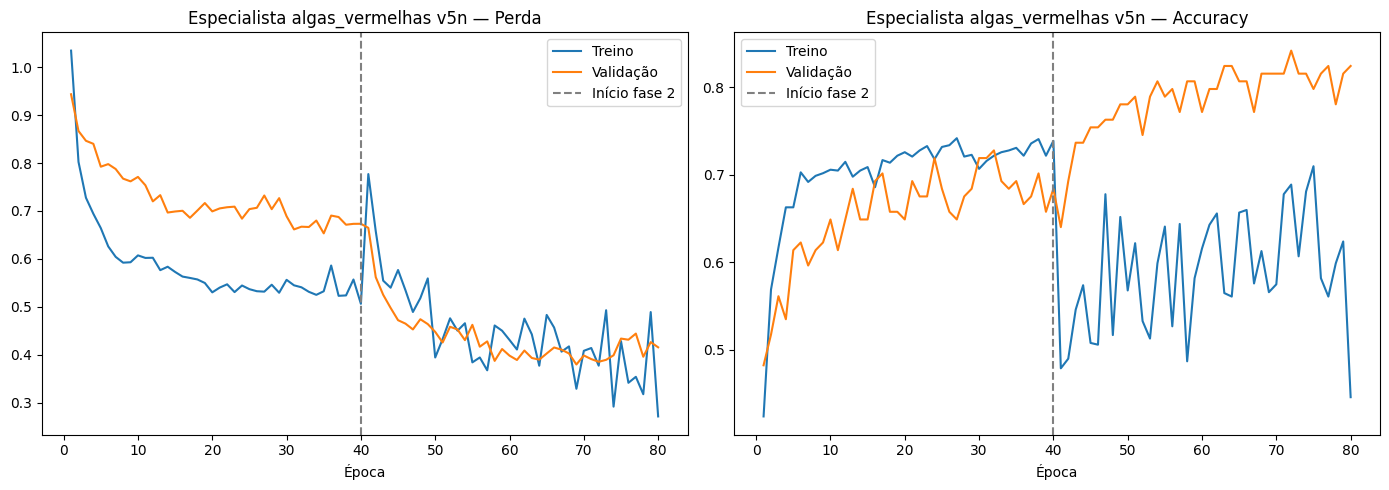


Especialista algas_vermelhas v5n — Teste desequilibrado
Balanced Accuracy:    0.7858
IC 95% (bootstrap):   [0.7070, 0.8574]
Cohen's Kappa:        0.7106
MCC:                  0.7114
Top-2 Accuracy:       0.9333
ROC-AUC (macro):      0.9434

                       precision    recall  f1-score   support

 Filamentosa_vermelha       0.76      0.83      0.79        23
Mastocarpus_stellatus       0.64      0.74      0.68        19
 Osmundea_pinnatifida       0.79      0.75      0.77        40
 Porphyra_umbilicalis       0.88      0.83      0.85        53

             accuracy                           0.79       135
            macro avg       0.77      0.79      0.77       135
         weighted avg       0.80      0.79      0.79       135



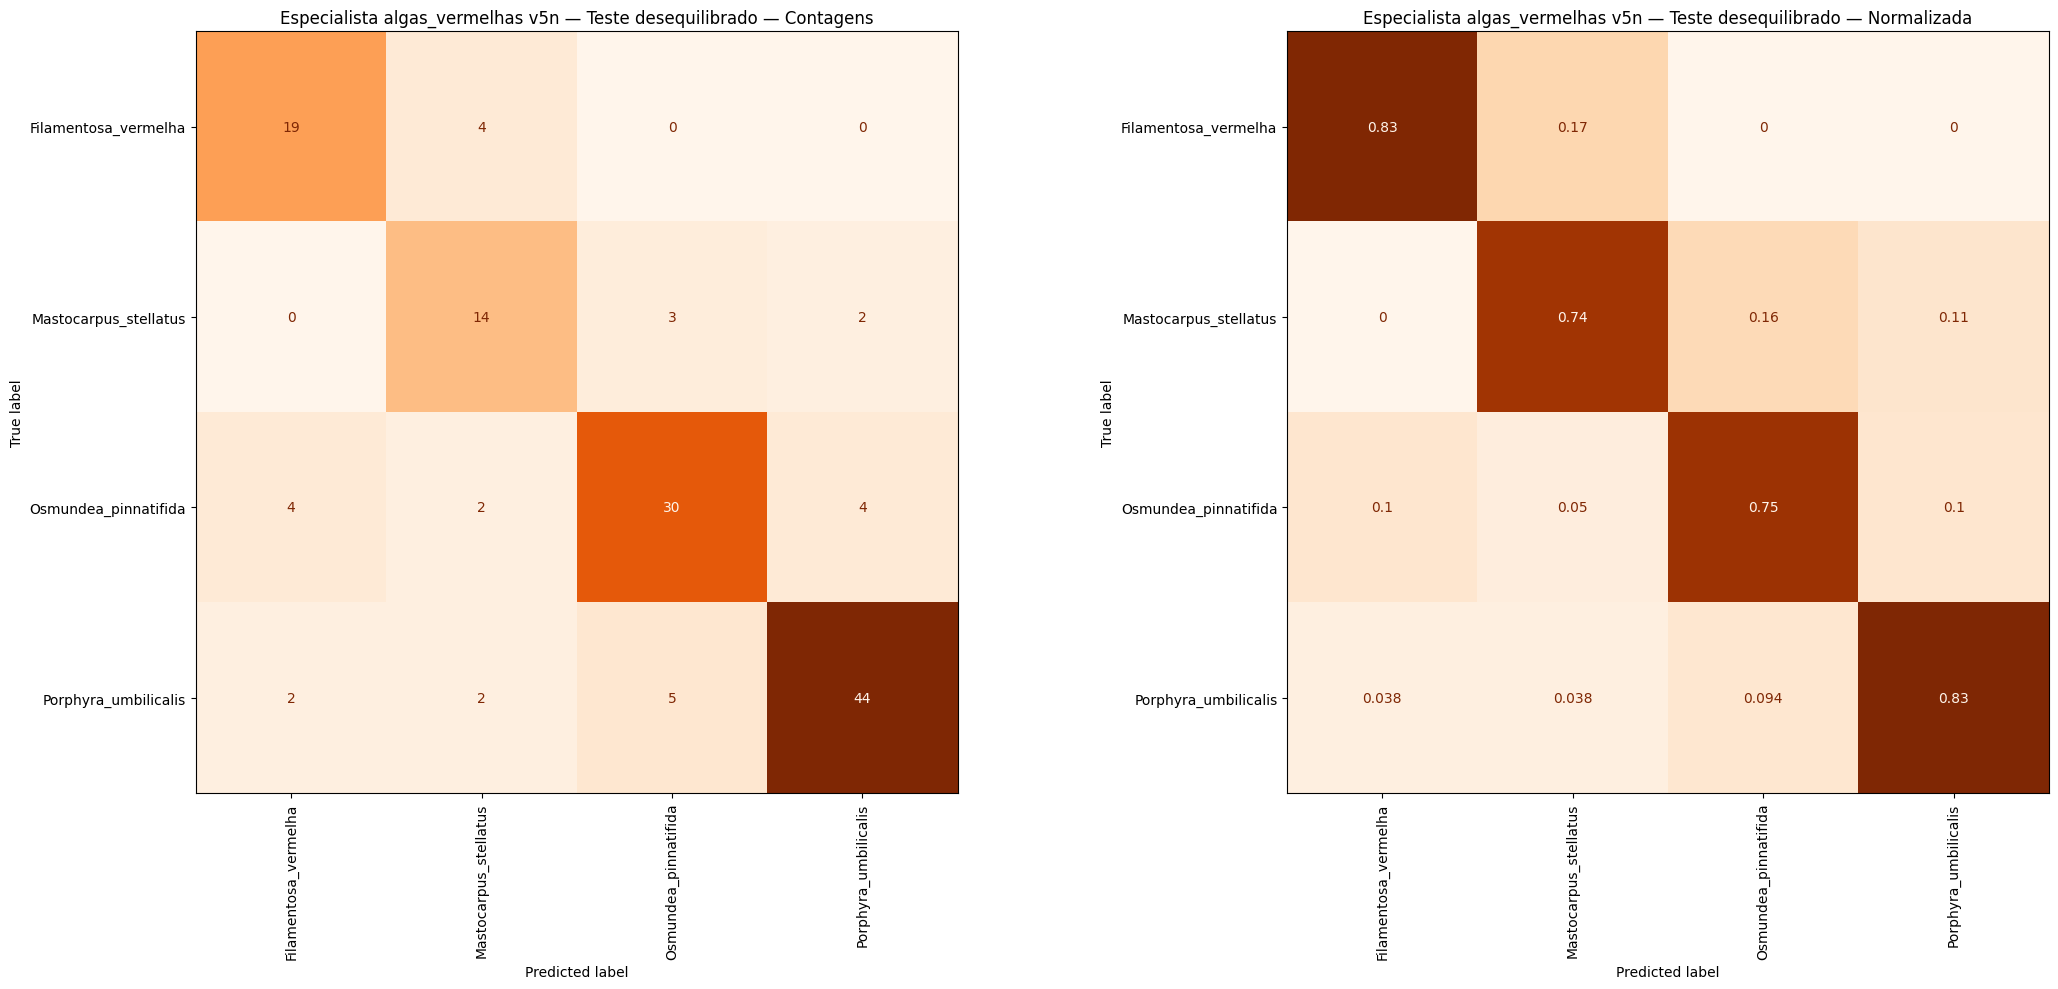

Top-10 confusões:
  Porphyra_umbilicalis → Osmundea_pinnatifida: 5
  Osmundea_pinnatifida → Porphyra_umbilicalis: 4
  Osmundea_pinnatifida → Filamentosa_vermelha: 4
  Filamentosa_vermelha → Mastocarpus_stellatus: 4
  Mastocarpus_stellatus → Osmundea_pinnatifida: 3
  Porphyra_umbilicalis → Mastocarpus_stellatus: 2
  Porphyra_umbilicalis → Filamentosa_vermelha: 2
  Osmundea_pinnatifida → Mastocarpus_stellatus: 2
  Mastocarpus_stellatus → Porphyra_umbilicalis: 2
✅ Especialista algas_vermelhas concluído.

ESPECIALISTA: algas_castanhas (2 espécies)
  train: 788 crops
  val: 101 crops
  test: 132 crops
  Oversample adaptativo:
    Ascophyllum_nudosum                   244 (sem oversample)
    Fucus_spp                             544 (sem oversample)

  Total: 788 amostras
  Classes: ['Ascophyllum_nudosum', 'Fucus_spp']

Época 1/40


Treino    — Loss: 0.3675 | Acc: 0.5914
Validação — Loss: 0.3083 | Acc: 0.7327
  → Guardado (val_acc=0.7327)

Época 2/40


Treino    — Loss: 0.2992 | Acc: 0.7170
Validação — Loss: 0.3127 | Acc: 0.6931
  → Sem melhoria (1/15)

Época 3/40


Treino    — Loss: 0.2886 | Acc: 0.7437
Validação — Loss: 0.3143 | Acc: 0.6733
  → Sem melhoria (2/15)

Época 4/40


Treino    — Loss: 0.2787 | Acc: 0.7551
Validação — Loss: 0.3019 | Acc: 0.7030
  → Sem melhoria (3/15)

Época 5/40


...

Treino    — Loss: 0.1934 | Acc: 0.8046
Validação — Loss: 0.1710 | Acc: 0.9109
  → Sem melhoria (11/15)

Época 29/40


Treino    — Loss: 0.1240 | Acc: 0.8122
Validação — Loss: 0.1715 | Acc: 0.9208
  → Sem melhoria (12/15)

Época 30/40


Treino    — Loss: 0.1604 | Acc: 0.7221
Validação — Loss: 0.1779 | Acc: 0.9010
  → Sem melhoria (13/15)

Época 31/40


Treino    — Loss: 0.1861 | Acc: 0.6954
Validação — Loss: 0.1661 | Acc: 0.8812
  → Sem melhoria (14/15)

Época 32/40


Treino    — Loss: 0.1552 | Acc: 0.7741
Validação — Loss: 0.1663 | Acc: 0.9109
  → Sem melhoria (15/15)

Early stopping na época 32.

Concluído. Melhor val_acc: 0.9208


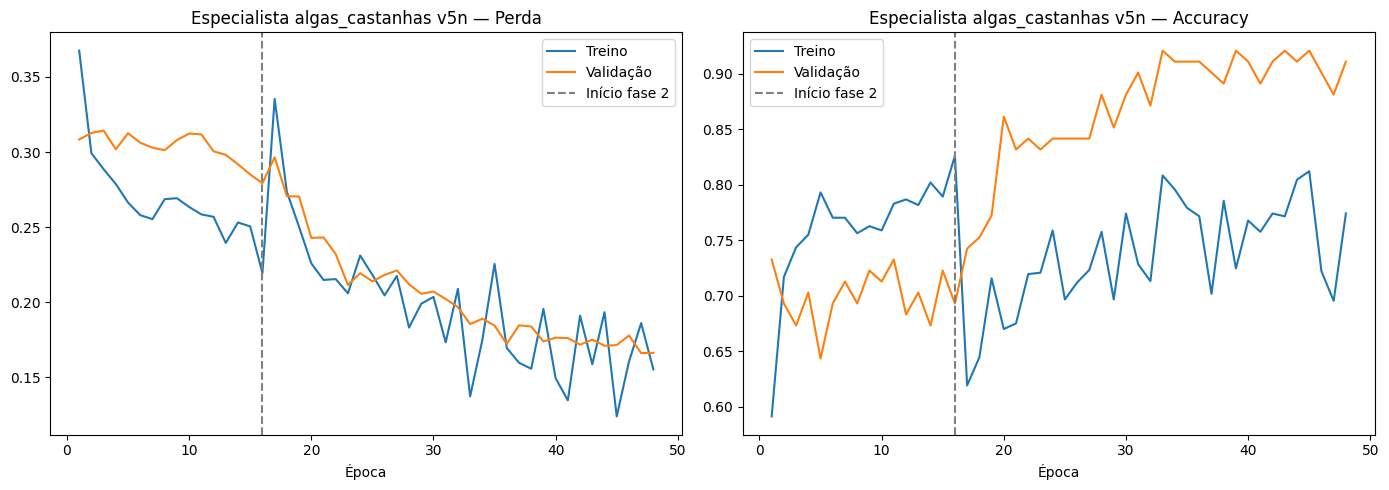


Especialista algas_castanhas v5n — Teste desequilibrado
Balanced Accuracy:    0.7868
IC 95% (bootstrap):   [0.7039, 0.8663]
Cohen's Kappa:        0.5212
MCC:                  0.5291
Top-2 Accuracy:       1.0000
ROC-AUC (macro):      nan

                     precision    recall  f1-score   support

Ascophyllum_nudosum       0.57      0.74      0.65        31
          Fucus_spp       0.91      0.83      0.87       101

           accuracy                           0.81       132
          macro avg       0.74      0.79      0.76       132
       weighted avg       0.83      0.81      0.82       132



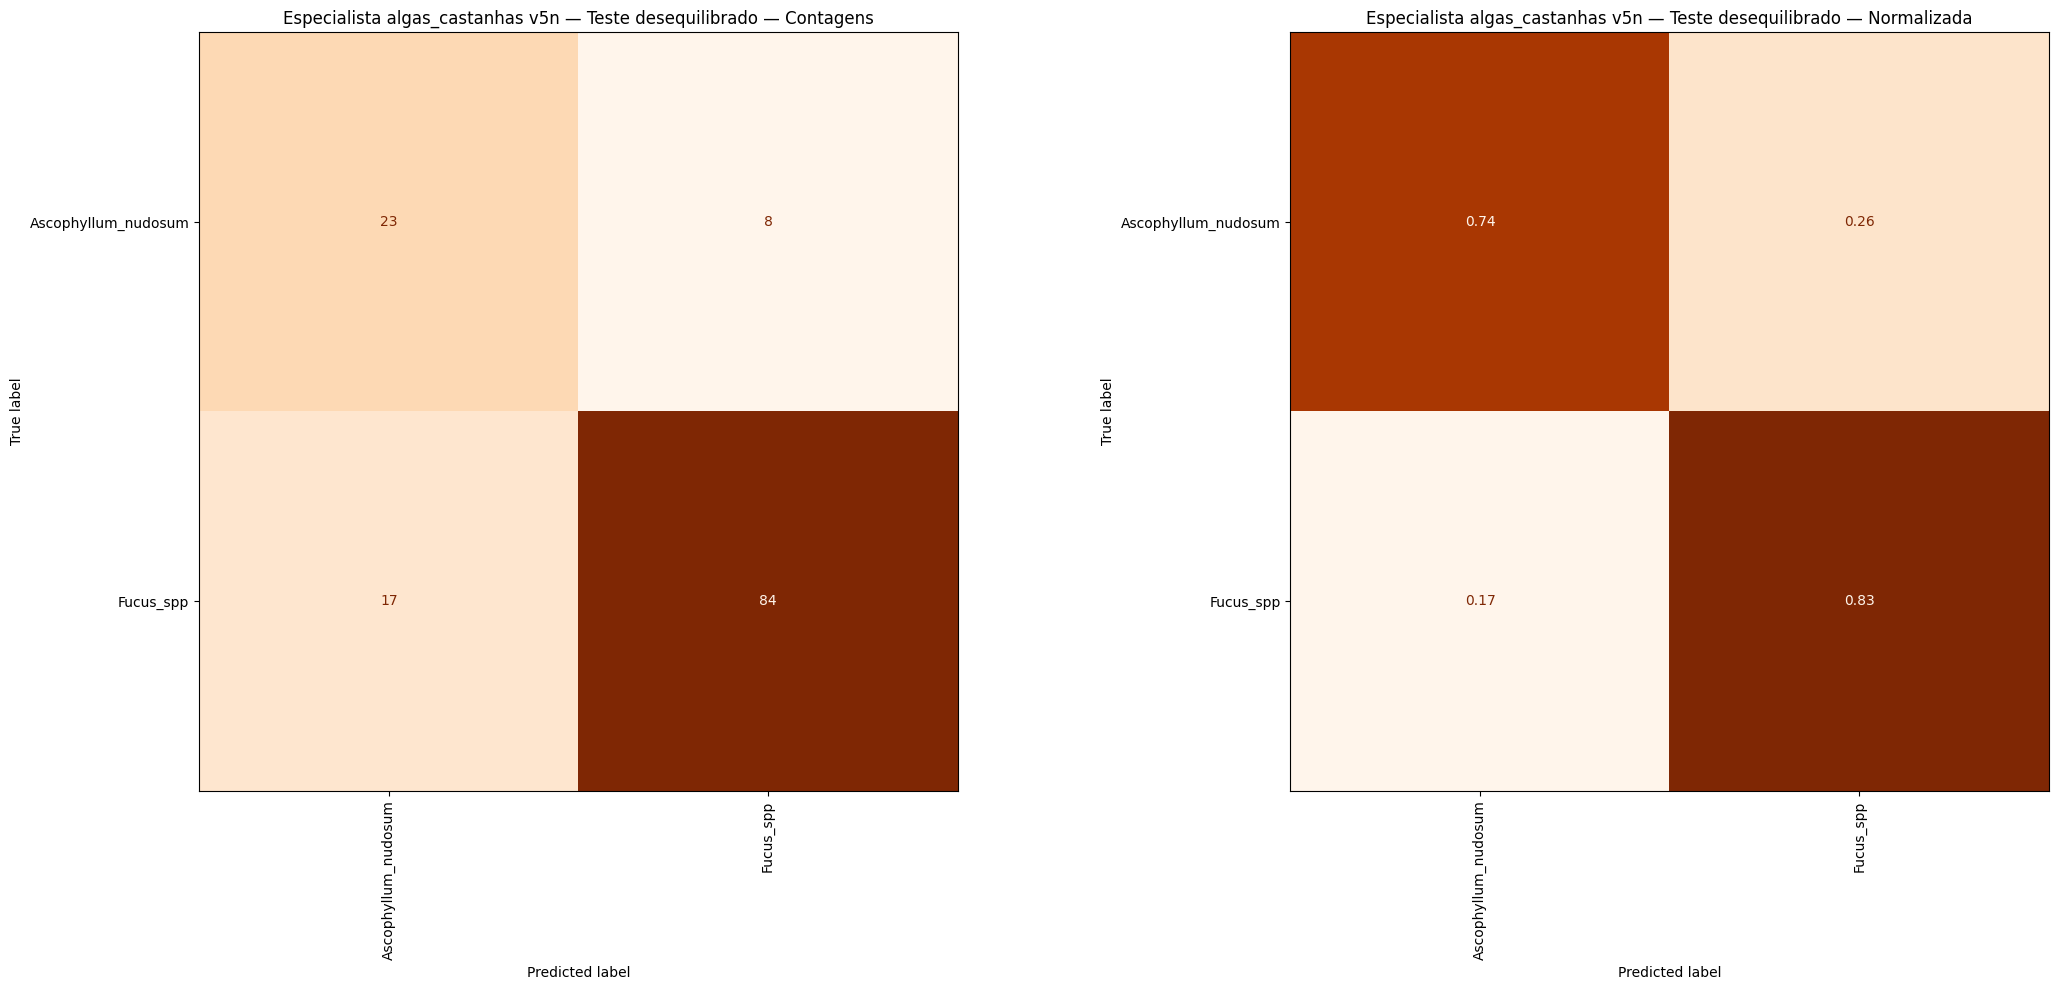

Top-10 confusões:
  Fucus_spp → Ascophyllum_nudosum: 17
  Ascophyllum_nudosum → Fucus_spp: 8
✅ Especialista algas_castanhas concluído.

ESPECIALISTA: cracas (2 espécies)
  train: 6563 crops
  val: 1408 crops
  test: 1377 crops
  Oversample adaptativo:
    Austrominius_modestus                 200 (sem oversample)
    Cracas                               6363 (sem oversample)

  Total: 6563 amostras
  Classes: ['Austrominius_modestus', 'Cracas']

Época 1/40


Treino    — Loss: 0.0229 | Acc: 0.5528
Validação — Loss: 0.0142 | Acc: 0.7166
  → Guardado (val_acc=0.7166)

Época 2/40


Treino    — Loss: 0.0147 | Acc: 0.7073
Validação — Loss: 0.0141 | Acc: 0.8629
  → Guardado (val_acc=0.8629)

Época 3/40


Treino    — Loss: 0.0126 | Acc: 0.7750
Validação — Loss: 0.0123 | Acc: 0.8409
  → Sem melhoria (1/15)

Época 4/40


Treino    — Loss: 0.0119 | Acc: 0.7903
Validação — Loss: 0.0157 | Acc: 0.8061
  → Sem melhoria (2/15)

Época 5/40


...

Treino    — Loss: 0.0079 | Acc: 0.8796
Validação — Loss: 0.0080 | Acc: 0.8885
  → Sem melhoria (11/15)

Época 28/40


Treino    — Loss: 0.0077 | Acc: 0.8819
Validação — Loss: 0.0076 | Acc: 0.9077
  → Sem melhoria (12/15)

Época 29/40


Treino    — Loss: 0.0083 | Acc: 0.8815
Validação — Loss: 0.0082 | Acc: 0.8572
  → Sem melhoria (13/15)

Época 30/40


Treino    — Loss: 0.0073 | Acc: 0.8801
Validação — Loss: 0.0075 | Acc: 0.9290
  → Sem melhoria (14/15)

Época 31/40


Treino    — Loss: 0.0092 | Acc: 0.8481
Validação — Loss: 0.0063 | Acc: 0.8928
  → Sem melhoria (15/15)

Early stopping na época 31.

Concluído. Melhor val_acc: 0.9787


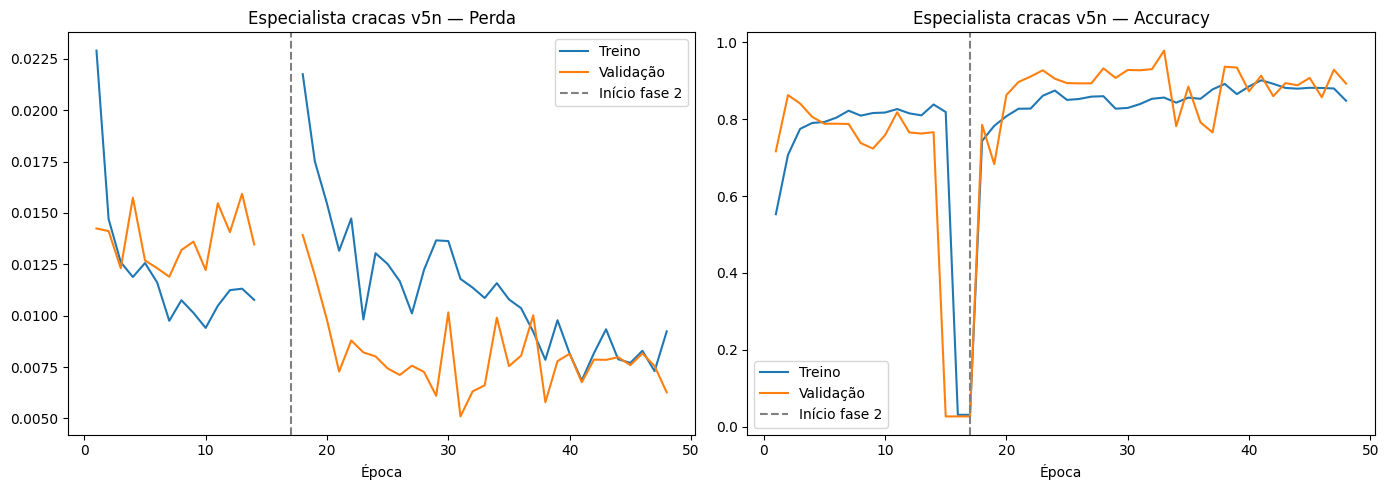


Especialista cracas v5n — Teste desequilibrado
Balanced Accuracy:    0.9865
IC 95% (bootstrap):   [0.9820, 0.9907]
Cohen's Kappa:        0.6774
MCC:                  0.7156
Top-2 Accuracy:       1.0000
ROC-AUC (macro):      nan

                       precision    recall  f1-score   support

Austrominius_modestus       0.53      1.00      0.69        40
               Cracas       1.00      0.97      0.99      1337

             accuracy                           0.97      1377
            macro avg       0.76      0.99      0.84      1377
         weighted avg       0.99      0.97      0.98      1377



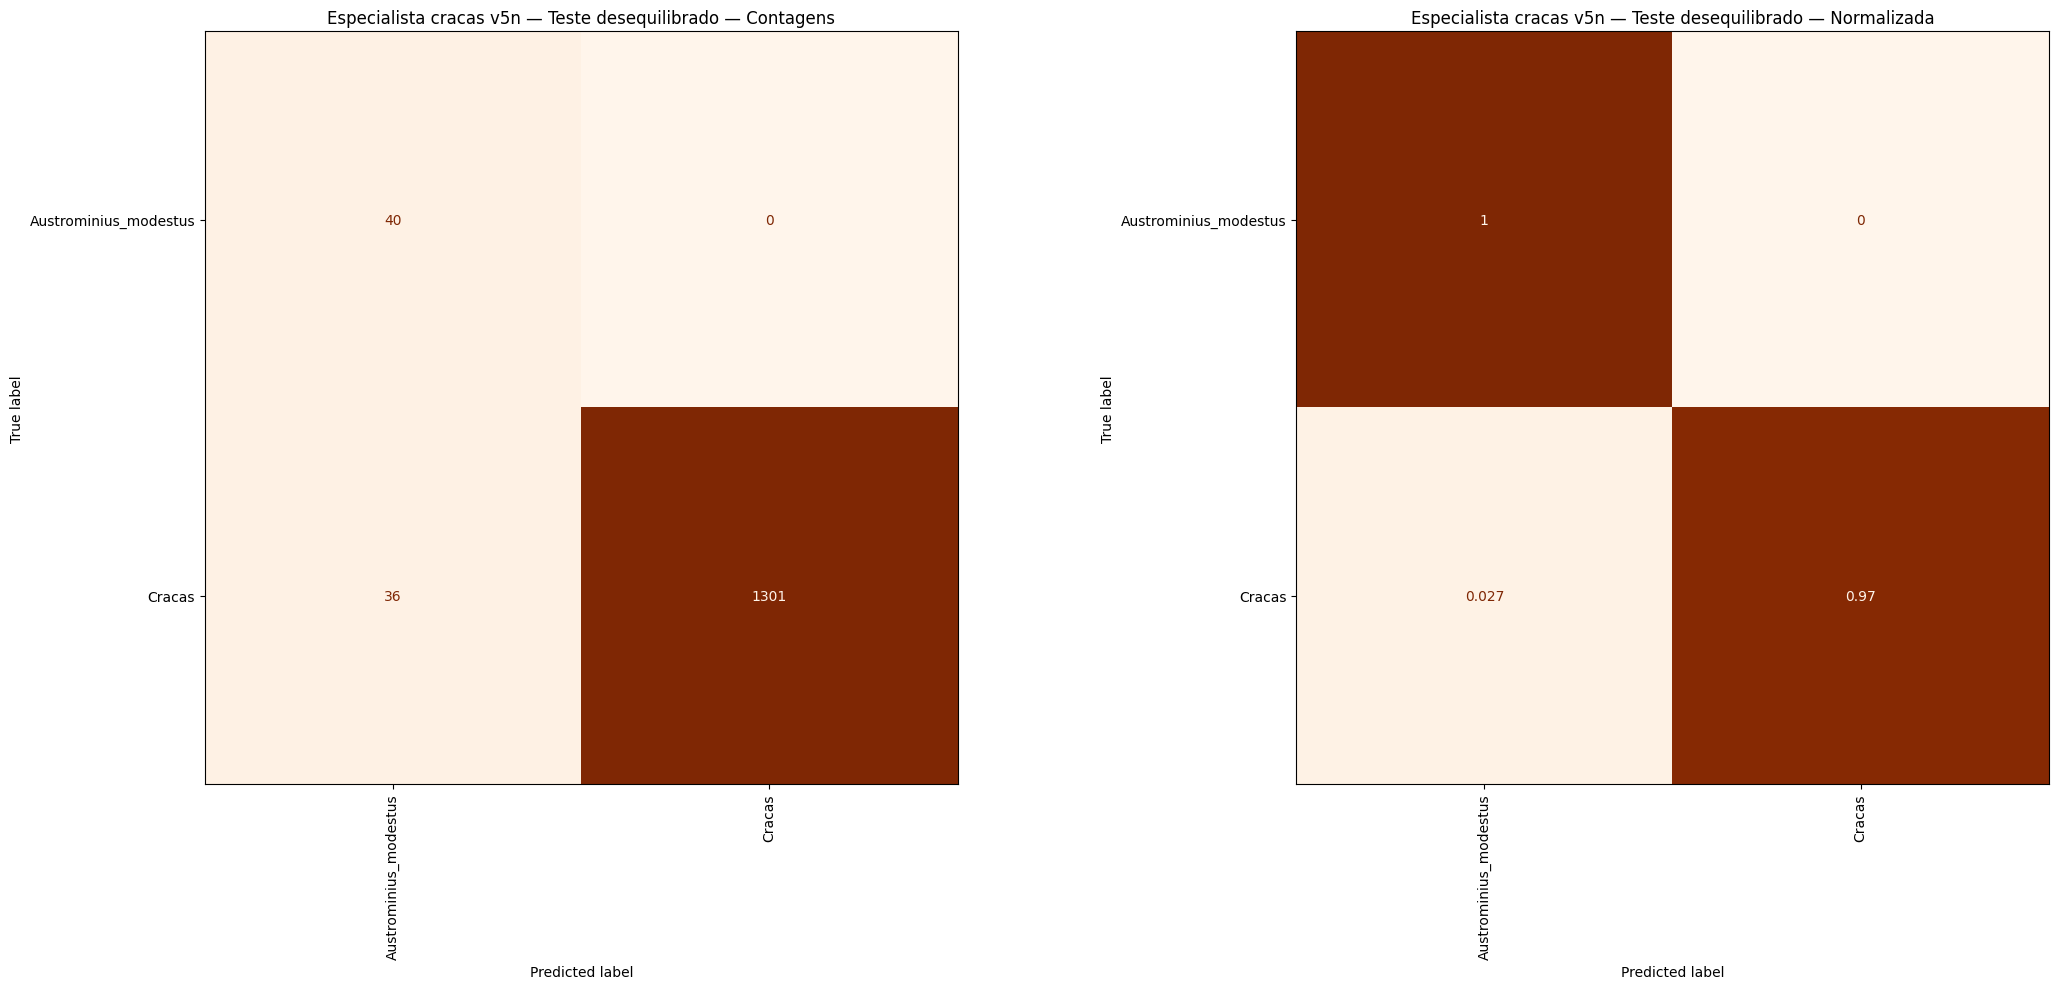

Top-10 confusões:
  Cracas → Austrominius_modestus: 36
✅ Especialista cracas concluído.

ESPECIALISTA: moluscos (6 espécies)
  train: 8966 crops
  val: 1879 crops
  test: 1849 crops
  Oversample adaptativo:
    Gibbula_umbilicalis                   764 (sem oversample)
    Littorina                              59 → 400 (+341)
    Mytilus                              3223 (sem oversample)
    Nucella_lapilus                       134 → 200 (+66)
    Patella                              4177 (sem oversample)
    Phorcus_sp                            609 (sem oversample)

  Total: 9373 amostras
  Classes: ['Gibbula_umbilicalis', 'Littorina', 'Mytilus', 'Nucella_lapilus', 'Patella', 'Phorcus_sp']

Época 1/40


Treino    — Loss: 0.1687 | Acc: 0.3738
Validação — Loss: 0.0797 | Acc: 0.4710
  → Guardado (val_acc=0.4710)

Época 2/40


Treino    — Loss: 0.1230 | Acc: 0.5040
Validação — Loss: 0.0805 | Acc: 0.4816
  → Guardado (val_acc=0.4816)

Época 3/40


Treino    — Loss: 0.1064 | Acc: 0.5257
Validação — Loss: 0.0739 | Acc: 0.5657
  → Guardado (val_acc=0.5657)

Época 4/40


Treino    — Loss: 0.1089 | Acc: 0.5508
Validação — Loss: 0.0730 | Acc: 0.5418
  → Sem melhoria (1/15)

Época 5/40


...

Treino    — Loss: 0.0703 | Acc: 0.5433
Validação — Loss: 0.0478 | Acc: 0.7424
  → Sem melhoria (8/15)

Época 37/40


Treino    — Loss: 0.0660 | Acc: 0.5113
Validação — Loss: 0.0448 | Acc: 0.7866
  → Sem melhoria (9/15)

Época 38/40


Treino    — Loss: 0.0673 | Acc: 0.5162
Validação — Loss: 0.0463 | Acc: 0.7690
  → Sem melhoria (10/15)

Época 39/40


Treino    — Loss: nan | Acc: 0.2428
Validação — Loss: nan | Acc: 0.0905
  → Sem melhoria (11/15)

Época 40/40


Treino    — Loss: nan | Acc: 0.0815
Validação — Loss: nan | Acc: 0.0905
  → Sem melhoria (12/15)

Concluído. Melhor val_acc: 0.8451


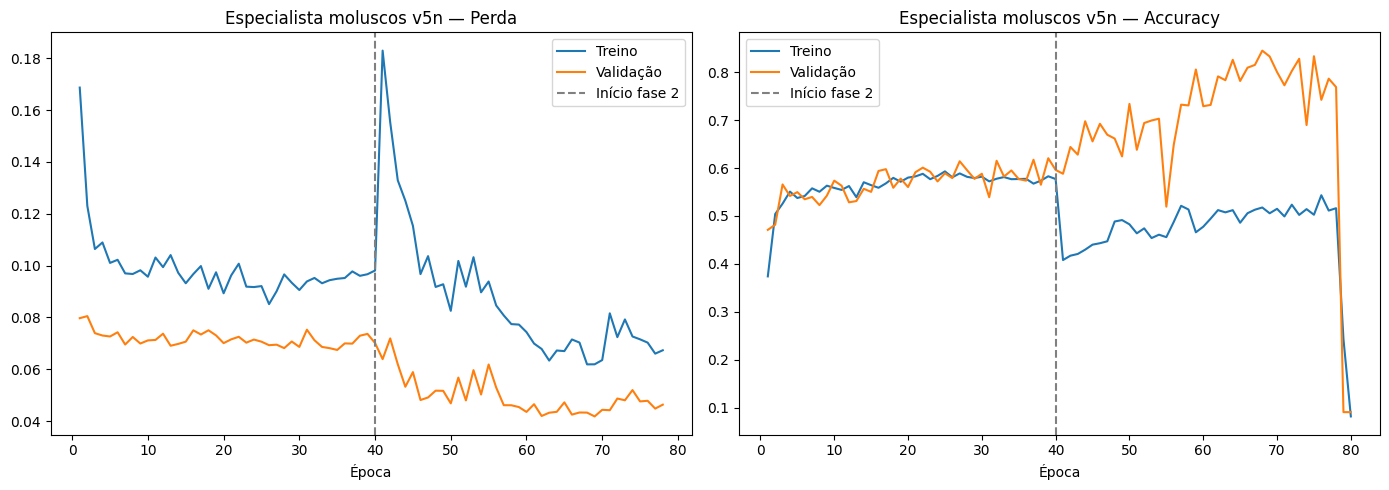


Especialista moluscos v5n — Teste desequilibrado
Balanced Accuracy:    0.7789
IC 95% (bootstrap):   [0.7400, 0.8163]
Cohen's Kappa:        0.7213
MCC:                  0.7281
Top-2 Accuracy:       0.9275
ROC-AUC (macro):      0.9487

                     precision    recall  f1-score   support

Gibbula_umbilicalis       0.62      0.78      0.69       197
          Littorina       0.17      1.00      0.29         8
            Mytilus       0.93      0.83      0.88       580
    Nucella_lapilus       0.16      0.56      0.25        25
            Patella       0.98      0.82      0.90       896
         Phorcus_sp       0.49      0.68      0.57       143

           accuracy                           0.81      1849
          macro avg       0.56      0.78      0.59      1849
       weighted avg       0.88      0.81      0.83      1849



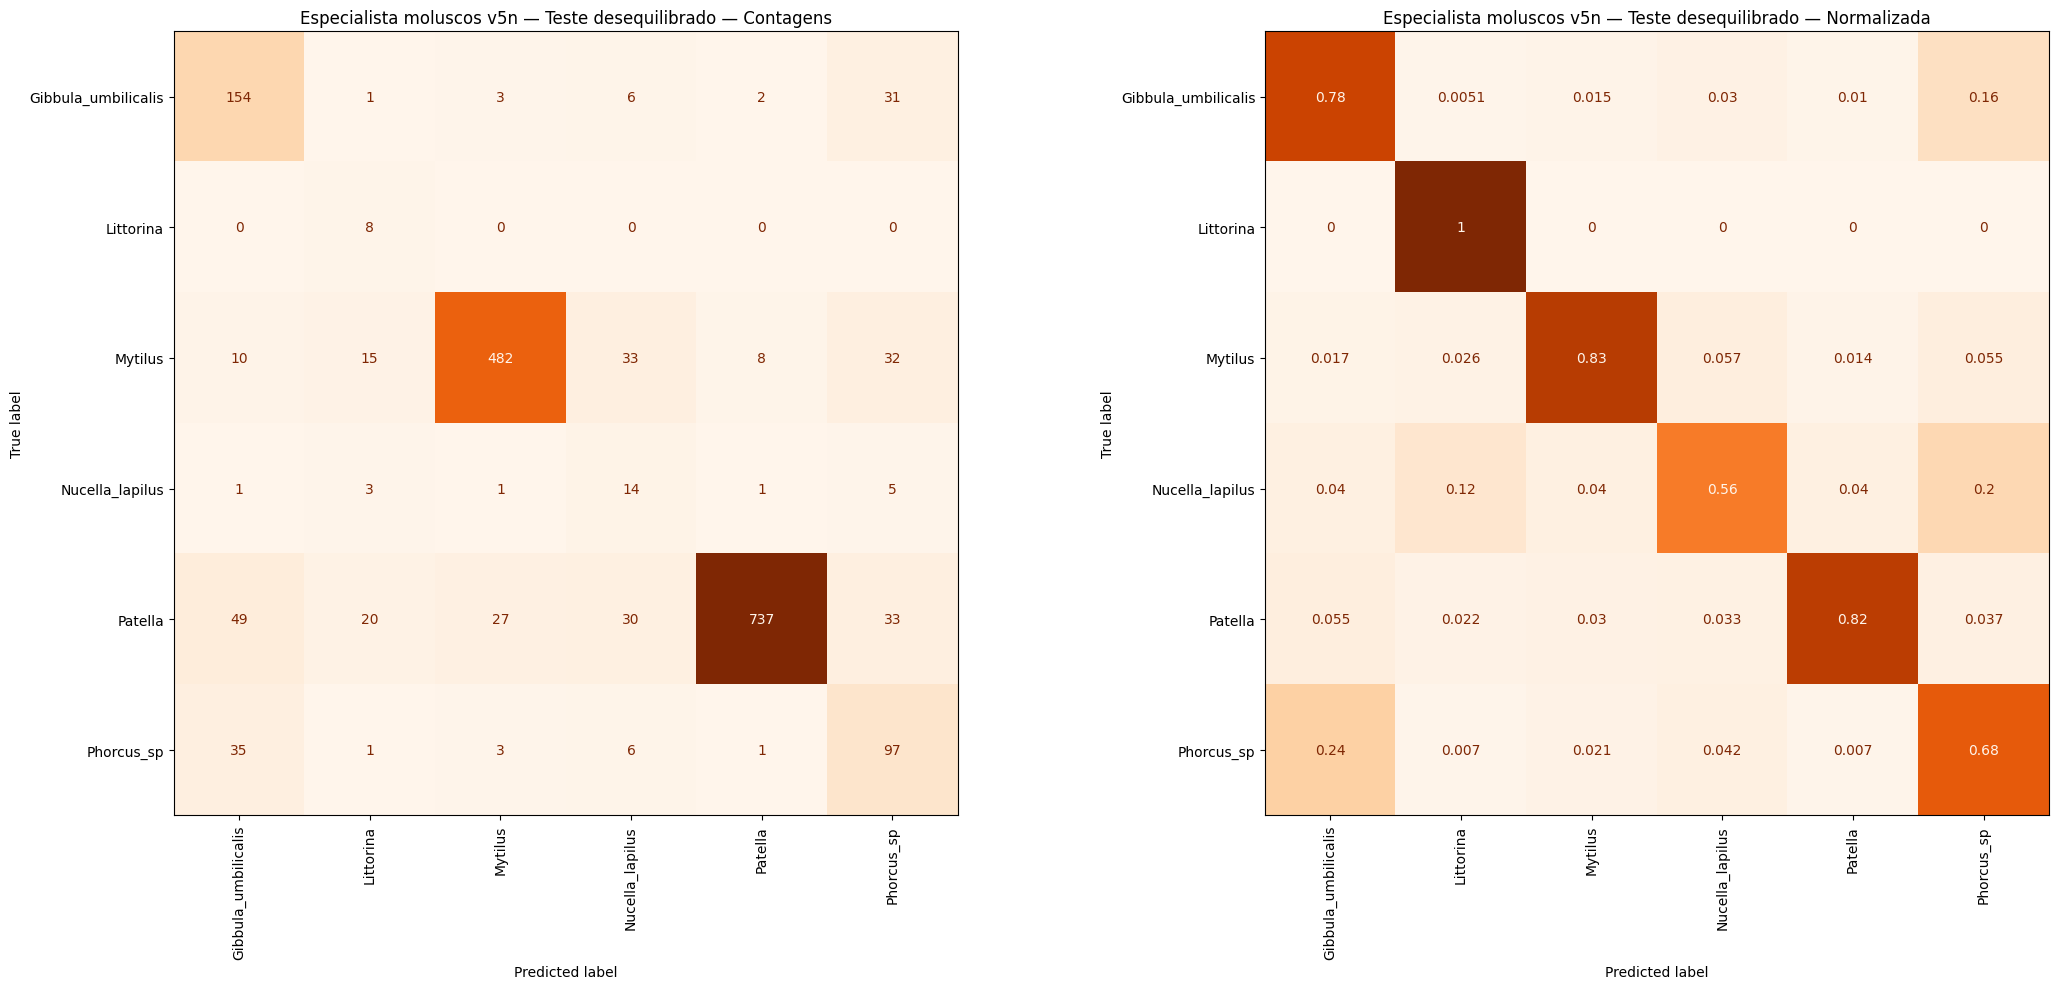

Top-10 confusões:
  Patella → Gibbula_umbilicalis: 49
  Phorcus_sp → Gibbula_umbilicalis: 35
  Patella → Phorcus_sp: 33
  Mytilus → Nucella_lapilus: 33
  Mytilus → Phorcus_sp: 32
  Gibbula_umbilicalis → Phorcus_sp: 31
  Patella → Nucella_lapilus: 30
  Patella → Mytilus: 27
  Patella → Littorina: 20
  Mytilus → Littorina: 15
✅ Especialista moluscos concluído.

ESPECIALISTA: outros_animais (2 espécies)
  train: 414 crops
  val: 88 crops
  test: 79 crops
  Oversample adaptativo:
    Actinia_equina                         52 → 400 (+348)
    Sabellaria_alveolata                  362 (sem oversample)

  Total: 762 amostras
  Classes: ['Actinia_equina', 'Sabellaria_alveolata']

Época 1/40


Treino    — Loss: 0.1953 | Acc: 0.5971
Validação — Loss: 0.0842 | Acc: 0.7500
  → Guardado (val_acc=0.7500)

Época 2/40


Treino    — Loss: 0.0812 | Acc: 0.8320
Validação — Loss: 0.0703 | Acc: 0.8636
  → Guardado (val_acc=0.8636)

Época 3/40


Treino    — Loss: 0.0570 | Acc: 0.8648
Validação — Loss: 0.0833 | Acc: 0.9205
  → Guardado (val_acc=0.9205)

Época 4/40


Treino    — Loss: 0.0510 | Acc: 0.9016
Validação — Loss: 0.0852 | Acc: 0.9091
  → Sem melhoria (1/15)

Época 5/40


...

Treino    — Loss: 0.0995 | Acc: 0.6102
Validação — Loss: 0.0317 | Acc: 0.8864
  → Sem melhoria (11/15)

Época 16/40


Treino    — Loss: 0.0752 | Acc: 0.7034
Validação — Loss: 0.0267 | Acc: 0.9318
  → Sem melhoria (12/15)

Época 17/40


Treino    — Loss: 0.0804 | Acc: 0.7415
Validação — Loss: 0.0318 | Acc: 0.8977
  → Sem melhoria (13/15)

Época 18/40


Treino    — Loss: 0.0797 | Acc: 0.6759
Validação — Loss: 0.0301 | Acc: 0.9205
  → Sem melhoria (14/15)

Época 19/40


Treino    — Loss: 0.0768 | Acc: 0.7940
Validação — Loss: 0.0320 | Acc: 0.8977
  → Sem melhoria (15/15)

Early stopping na época 19.

Concluído. Melhor val_acc: 0.9659


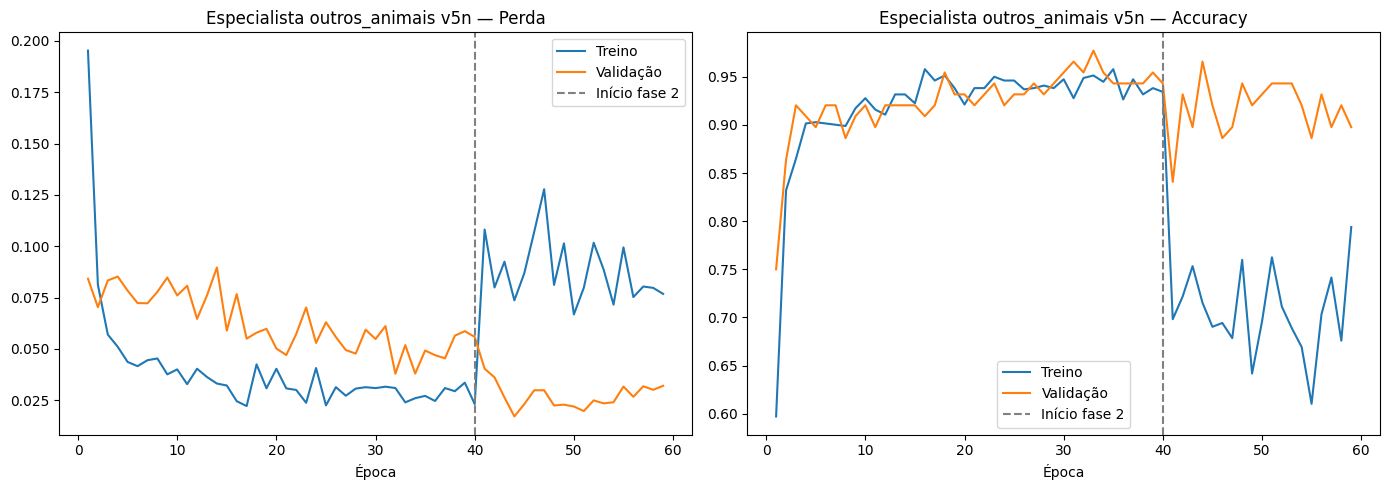


Especialista outros_animais v5n — Teste desequilibrado
Balanced Accuracy:    1.0000
IC 95% (bootstrap):   [1.0000, 1.0000]
Cohen's Kappa:        1.0000
MCC:                  1.0000
Top-2 Accuracy:       1.0000
ROC-AUC (macro):      nan

                      precision    recall  f1-score   support

      Actinia_equina       1.00      1.00      1.00        12
Sabellaria_alveolata       1.00      1.00      1.00        67

            accuracy                           1.00        79
           macro avg       1.00      1.00      1.00        79
        weighted avg       1.00      1.00      1.00        79



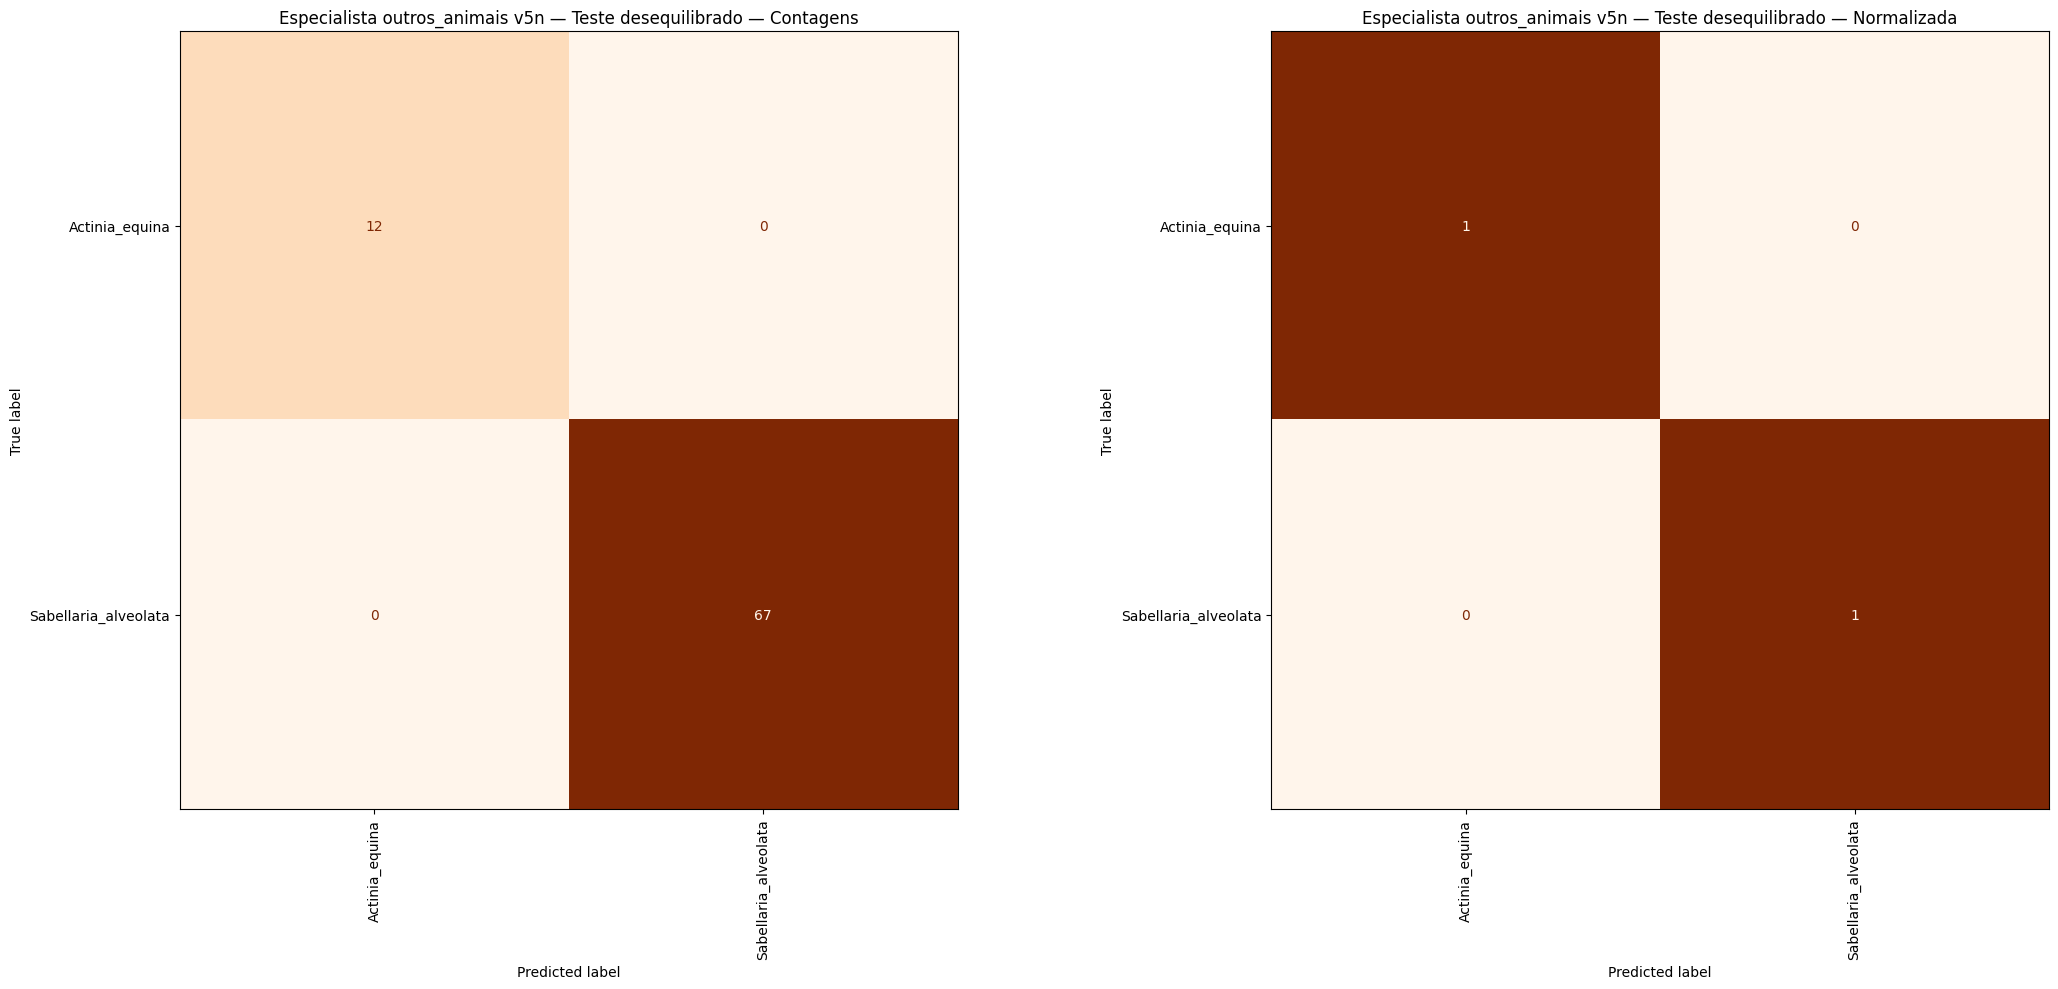

Top-10 confusões:
✅ Especialista outros_animais concluído.


In [9]:
GRUPOS_COM_ESPECIALISTA = {k: v for k, v in GRUPOS.items() if len(v) > 1}
models_l2  = {}
classes_l2 = {}

for grupo, especies in GRUPOS_COM_ESPECIALISTA.items():
    print(f"\n{'='*55}")
    print(f"ESPECIALISTA: {grupo} ({len(especies)} espécies)")
    print(f"{'='*55}")

    DIR_TR = f"/kaggle/working/esp_{grupo}/train"
    DIR_VL = f"/kaggle/working/esp_{grupo}/val"
    DIR_TE = f"/kaggle/working/esp_{grupo}/test"

    for split, pasta_src, pasta_dst in [
        ("train", BASE_CROPS_TRAIN, DIR_TR),
        ("val",   BASE_CROPS_VAL,   DIR_VL),
        ("test",  BASE_CROPS_TEST,  DIR_TE),
    ]:
        if os.path.exists(pasta_dst): shutil.rmtree(pasta_dst)
        os.makedirs(pasta_dst, exist_ok=True)
        for esp in especies:
            src = os.path.join(pasta_src, esp)
            if not os.path.exists(src): continue
            shutil.copytree(src, os.path.join(pasta_dst, esp))
        total = sum(len(os.listdir(os.path.join(pasta_dst, e)))
                    for e in os.listdir(pasta_dst)
                    if os.path.isdir(os.path.join(pasta_dst, e)))
        print(f"  {split}: {total} crops")

    train_ds_esp = OversampledDataset(DIR_TR)
    val_ds_esp   = datasets.ImageFolder(DIR_VL, transform=val_test_transforms)
    test_ds_esp  = datasets.ImageFolder(DIR_TE, transform=val_test_transforms)

    train_esp = DataLoader(train_ds_esp, batch_size=32, shuffle=True,  num_workers=2)
    val_esp   = DataLoader(val_ds_esp,   batch_size=32, shuffle=False, num_workers=2)
    test_esp  = DataLoader(test_ds_esp,  batch_size=32, shuffle=False, num_workers=2)

    cls_esp = train_ds_esp.classes
    classes_l2[grupo] = cls_esp
    print(f"  Classes: {cls_esp}")

    counts_esp = torch.tensor([len(os.listdir(os.path.join(DIR_TR, cls)))
                                for cls in cls_esp], dtype=torch.float)
    w_esp    = 1.0/counts_esp; w_esp = w_esp/w_esp.sum()*len(cls_esp)
    crit_esp = FocalLoss(alpha=w_esp.to(device), gamma=0.5)  # gamma=0.5 correcto — era 2.0 no v5i por engano

    SAVE_ESP = f"/kaggle/working/best_l2_{grupo}_v5n.pth"

    # Fase 1 — sem Mixup (backbone congelado)
    m = build_efficientnet_b0(len(cls_esp), device, freeze_backbone=True)
    opt1 = optim.Adam(m.classifier.parameters(), lr=0.001)
    sch1 = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt1, T_0=10, T_mult=2)
    tl1,vl1,ta1,va1 = train_model_early_stop(
        m, train_esp, val_esp, crit_esp, opt1, SAVE_ESP,
        num_epochs=40, scheduler=sch1, patience=15, use_mixup=False)

    m.load_state_dict(torch.load(SAVE_ESP, map_location=device))
    print(f"  ✓ Melhor checkpoint fase 1 carregado para {grupo}")

    # Fase 2 — com Mixup (lr=1e-4)
    for p in m.parameters(): p.requires_grad = True
    opt2 = optim.Adam(m.parameters(), lr=1e-4)
    sch2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt2, T_0=10, T_mult=2)
    tl2,vl2,ta2,va2 = train_model_early_stop(
        m, train_esp, val_esp, crit_esp, opt2, SAVE_ESP,
        num_epochs=40, scheduler=sch2, patience=15, use_mixup=True)

    plot_curves(tl1+tl2, vl1+vl2, ta1+ta2, va1+va2,
                f"Especialista {grupo} v5n", vline=len(tl1))

    m.load_state_dict(torch.load(SAVE_ESP, map_location=device))
    _, acc_esp, labels_esp, preds_esp, probs_esp = evaluate(
        m, test_esp, FocalLoss(), device)
    compute_all_metrics(labels_esp, preds_esp, probs_esp, cls_esp,
                        f"Especialista {grupo} v5n — Teste desequilibrado", "Oranges")

    models_l2[grupo] = m
    print(f"✅ Especialista {grupo} concluído.")

## 9. Avaliação do pipeline hierárquico com TTA

Inferência hierárquica completa:
1. Nível 1 determina o grupo biológico
2. Especialista de nível 2 determina a espécie dentro do grupo
3. Se o grupo tem apenas uma espécie, é atribuída diretamente

TTA com 5 passes por imagem; as probabilidades de cada pass são calculadas em média antes de determinar a classe final. Avaliação no conjunto de teste balanceado.

A avaliar pipeline com TTA no teste balanceado...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



Pipeline Hierárquico v5n — Teste Balanceado + TTA
Balanced Accuracy:    0.7794
IC 95% (bootstrap):   [0.7064, 0.8415]
Cohen's Kappa:        0.7656
MCC:                  0.7669
Top-2 Accuracy:       0.7868
ROC-AUC (macro):      0.8828

                       precision    recall  f1-score   support

       Actinia_equina       1.00      0.88      0.93         8
  Ascophyllum_nudosum       0.78      0.88      0.82         8
Austrominius_modestus       0.89      1.00      0.94         8
               Cracas       0.78      0.88      0.82         8
 Filamentosa_vermelha       0.83      0.62      0.71         8
            Fucus_spp       0.62      0.62      0.62         8
  Gibbula_umbilicalis       0.78      0.88      0.82         8
            Littorina       0.75      0.75      0.75         8
Mastocarpus_stellatus       0.70      0.88      0.78         8
              Mytilus       0.73      1.00      0.84         8
      Nucella_lapilus       0.50      0.25      0.33         8
 Osmund

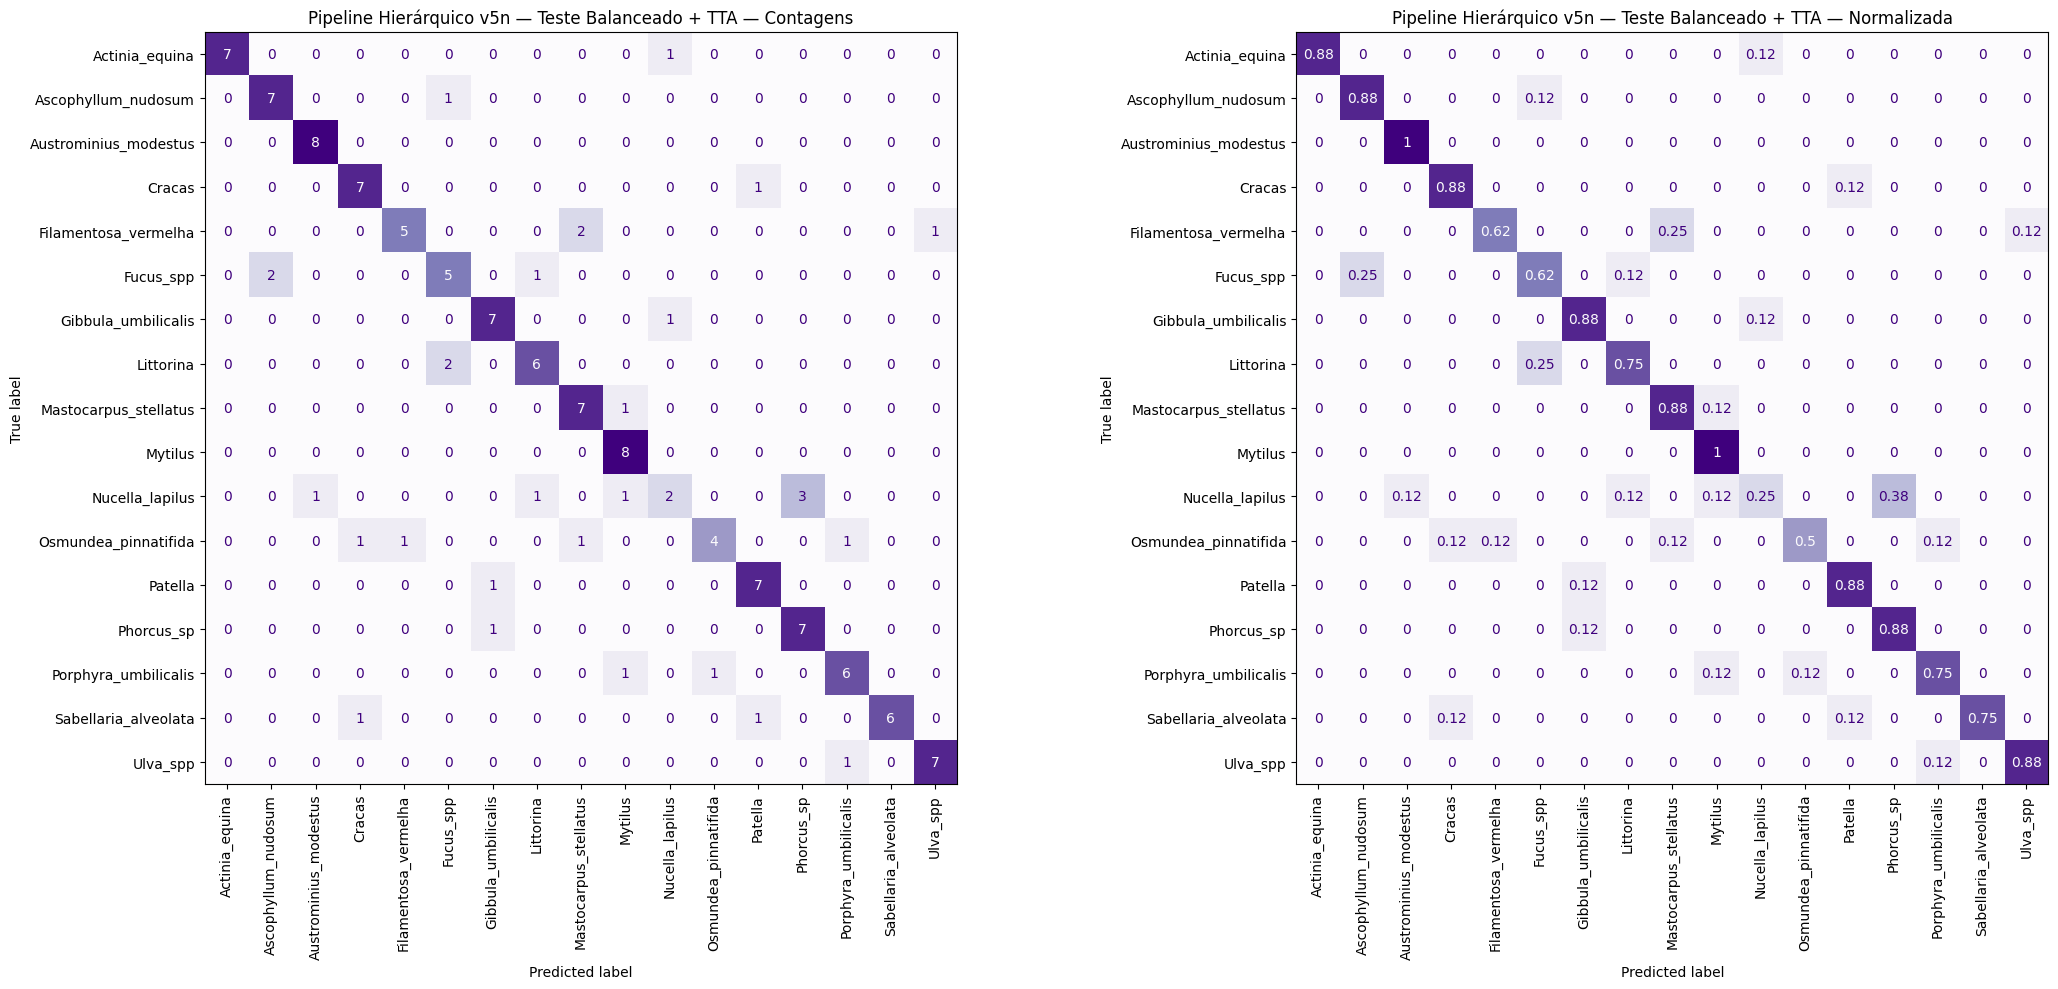

Top-10 confusões:
  Nucella_lapilus → Phorcus_sp: 3
  Littorina → Fucus_spp: 2
  Fucus_spp → Ascophyllum_nudosum: 2
  Filamentosa_vermelha → Mastocarpus_stellatus: 2
  Ulva_spp → Porphyra_umbilicalis: 1
  Sabellaria_alveolata → Patella: 1
  Sabellaria_alveolata → Cracas: 1
  Porphyra_umbilicalis → Osmundea_pinnatifida: 1
  Porphyra_umbilicalis → Mytilus: 1
  Phorcus_sp → Gibbula_umbilicalis: 1

Total de erros: 30
  Nível 1: 13 (43.3%)
  Nível 2: 17 (56.7%)


In [10]:
def hierarquical_predict_tta(imgs_pil_list, model_l1, models_l2, classes_l2,
                              class_names_l1, grupos, device, tta_transforms):
    preds_especies, confs = [], []
    for img_pil in imgs_pil_list:
        probs_l1_tta = []
        model_l1.eval()
        for t in tta_transforms:
            tensor = t(img_pil).unsqueeze(0).to(device)
            with torch.no_grad():
                probs_l1_tta.append(F.softmax(model_l1(tensor), dim=1))
        probs_l1   = torch.stack(probs_l1_tta).mean(0)[0]
        grupo_idx  = probs_l1.argmax().item()
        grupo_nome = class_names_l1[grupo_idx]
        especies_do_grupo = grupos.get(grupo_nome, [])

        if len(especies_do_grupo) == 1:
            preds_especies.append(especies_do_grupo[0])
            confs.append(probs_l1[grupo_idx].item())
        elif grupo_nome in models_l2:
            m2 = models_l2[grupo_nome]; m2.eval()
            probs_l2_tta = []
            for t in tta_transforms:
                tensor = t(img_pil).unsqueeze(0).to(device)
                with torch.no_grad():
                    probs_l2_tta.append(F.softmax(m2(tensor), dim=1))
            probs_l2 = torch.stack(probs_l2_tta).mean(0)[0]
            esp_idx  = probs_l2.argmax().item()
            preds_especies.append(classes_l2[grupo_nome][esp_idx])
            confs.append(probs_l2[esp_idx].item())
        else:
            preds_especies.append(grupo_nome)
            confs.append(probs_l1[grupo_idx].item())
    return preds_especies, confs

print("A avaliar pipeline com TTA no teste balanceado...")
all_true, all_pred, all_conf = [], [], []

for cls_name in sorted(os.listdir(BASE_CROPS_TEST_BAL)):
    cls_dir = os.path.join(BASE_CROPS_TEST_BAL, cls_name)
    if not os.path.isdir(cls_dir): continue
    for img_file in os.listdir(cls_dir):
        img_pil = Image.open(os.path.join(cls_dir, img_file)).convert("RGB")
        preds, confs = hierarquical_predict_tta(
            [img_pil], model_l1, models_l2, classes_l2,
            class_names_l1, GRUPOS, device, tta_transforms)
        all_true.append(cls_name)
        all_pred.append(preds[0])
        all_conf.append(confs[0])

cls_to_idx    = {c: i for i, c in enumerate(sorted(set(all_true)))}
labels_idx    = [cls_to_idx[t] for t in all_true]
preds_idx     = [cls_to_idx.get(p, -1) for p in all_pred]
sorted_classes = sorted(set(all_true))
n_cls_plot    = len(sorted_classes)

probs_onehot = np.zeros((len(preds_idx), n_cls_plot))
for i, p in enumerate(preds_idx):
    if 0 <= p < n_cls_plot:
        probs_onehot[i, p] = 1.0

metrics_v5n = compute_all_metrics(
    labels_idx, preds_idx, probs_onehot, sorted_classes,
    "Pipeline Hierárquico v5n — Teste Balanceado + TTA", "Purples")

erros_nivel1, erros_nivel2 = 0, 0
for t, p in zip(all_true, all_pred):
    if t == p: continue
    gr = next((g for g,es in GRUPOS.items() if t in es), "?")
    gp = next((g for g,es in GRUPOS.items() if p in es), "?")
    if gr != gp: erros_nivel1 += 1
    else: erros_nivel2 += 1
total_erros = erros_nivel1 + erros_nivel2
if total_erros > 0:
    print(f"\nTotal de erros: {total_erros}")
    print(f"  Nível 1: {erros_nivel1} ({erros_nivel1/total_erros*100:.1f}%)")
    print(f"  Nível 2: {erros_nivel2} ({erros_nivel2/total_erros*100:.1f}%)")

## 10. Determinação do limiar de confiança (threshold)

O threshold é determinado no conjunto de **validação** (não no teste) para evitar data leakage. Para cada valor de threshold entre 0,30 e 0,90, calcula-se a balanced accuracy nas predições aceites e a percentagem de crops rejeitados.

Critério de seleção: **maximizar balanced accuracy com taxa de rejeição < 20%**.

A calcular threshold na validação com TTA...

 Threshold  Bal Acc (val)  % Rejeit.
----------------------------------------
      0.30         0.7774       0.6%
      0.35         0.7799       1.9%
      0.40         0.7908       3.5%
      0.45         0.8019       6.0%
      0.50         0.8140       9.7%
      0.55         0.8270      14.3%
      0.60         0.8448      19.2%
      0.65         0.8602      25.6%
      0.70         0.8703      33.8%
      0.75         0.8817      44.2%
      0.80         0.8921      56.9%
      0.85         0.8948      71.6%
      0.90         0.9134      85.2%

Threshold óptimo: 0.60


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics


Teste com threshold=0.60:
  Balanced Accuracy: 0.8380 (IC 95%: [0.7690, 0.9078])
  Cohen's Kappa:     0.8257
  MCC:               0.8269
  % Rejeitados:      19.1%


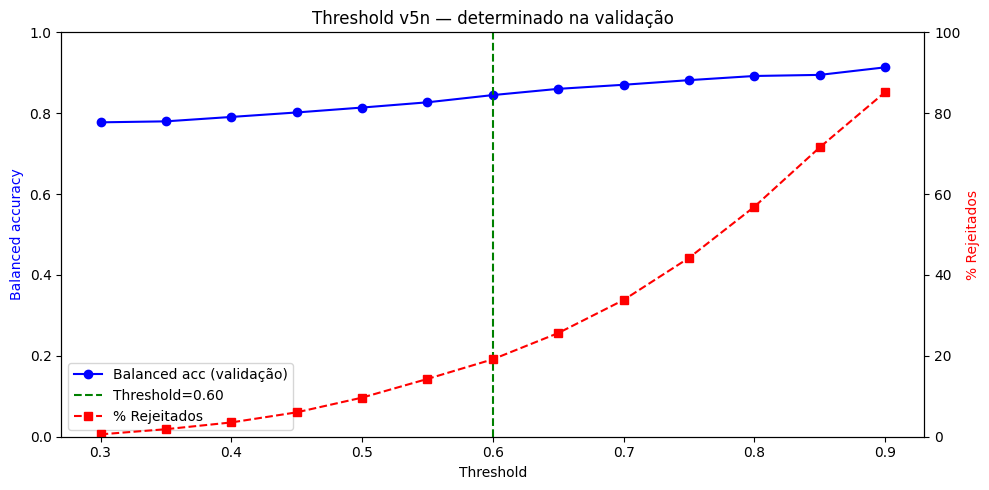

In [11]:
print("A calcular threshold na validação com TTA...")
val_true, val_pred, val_conf = [], [], []

for cls_name in sorted(os.listdir(BASE_CROPS_VAL)):
    cls_dir = os.path.join(BASE_CROPS_VAL, cls_name)
    if not os.path.isdir(cls_dir): continue
    for img_file in os.listdir(cls_dir):
        img_pil = Image.open(os.path.join(cls_dir, img_file)).convert("RGB")
        preds, confs = hierarquical_predict_tta(
            [img_pil], model_l1, models_l2, classes_l2,
            class_names_l1, GRUPOS, device, tta_transforms)
        val_true.append(cls_name)
        val_pred.append(preds[0])
        val_conf.append(confs[0])

thresholds = np.arange(0.30, 0.95, 0.05)
resultados_val = []
for thresh in thresholds:
    true_f, pred_f = [], []
    n_rej = 0
    for t, p, c in zip(val_true, val_pred, val_conf):
        if c >= thresh: true_f.append(t); pred_f.append(p)
        else: n_rej += 1
    if not true_f: continue
    bal = balanced_accuracy_score(true_f, pred_f)
    pct = n_rej / len(val_conf) * 100
    resultados_val.append((thresh, bal, pct, n_rej))

print(f"\n{'Threshold':>10} {'Bal Acc (val)':>14} {'% Rejeit.':>10}")
print("-"*40)
for thresh, bal, pct, n_rej in resultados_val:
    print(f"{thresh:>10.2f} {bal:>14.4f} {pct:>9.1f}%")

melhor_val = max((r for r in resultados_val if r[2] < 20.0),
                  key=lambda r: r[1], default=None)
THRESHOLD_OPTIMO = melhor_val[0] if melhor_val else 0.5
print(f"\nThreshold óptimo: {THRESHOLD_OPTIMO:.2f}")

true_thresh, pred_thresh = [], []
n_rej_test = 0
for t, p, c in zip(all_true, all_pred, all_conf):
    if c >= THRESHOLD_OPTIMO:
        true_thresh.append(t); pred_thresh.append(p)
    else:
        n_rej_test += 1

pct_rej_test = n_rej_test / len(all_true) * 100
bal_thresh   = balanced_accuracy_score(true_thresh, pred_thresh)
kappa_thresh = cohen_kappa_score(true_thresh, pred_thresh)
mcc_thresh   = matthews_corrcoef(true_thresh, pred_thresh)
_, ci_low_t, ci_high_t = bootstrap_ci(
    [cls_to_idx[t] for t in true_thresh],
    [cls_to_idx.get(p,-1) for p in pred_thresh], BOOTSTRAP_N)

print(f"\nTeste com threshold={THRESHOLD_OPTIMO:.2f}:")
print(f"  Balanced Accuracy: {bal_thresh:.4f} (IC 95%: [{ci_low_t:.4f}, {ci_high_t:.4f}])")
print(f"  Cohen's Kappa:     {kappa_thresh:.4f}")
print(f"  MCC:               {mcc_thresh:.4f}")
print(f"  % Rejeitados:      {pct_rej_test:.1f}%")

# Gráfico threshold
fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ts  = [r[0] for r in resultados_val]
bs  = [r[1] for r in resultados_val]
rjs = [r[2] for r in resultados_val]
ax1.plot(ts, bs,  "b-o", label="Balanced acc (validação)")
ax2.plot(ts, rjs, "r--s", label="% Rejeitados")
ax1.axvline(x=THRESHOLD_OPTIMO, color="green", linestyle="--",
            label=f"Threshold={THRESHOLD_OPTIMO:.2f}")
ax1.set_xlabel("Threshold"); ax1.set_ylabel("Balanced accuracy", color="b")
ax2.set_ylabel("% Rejeitados", color="r")
ax1.set_ylim(0,1); ax2.set_ylim(0,100)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
lbls  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, lbls, loc="lower left")
plt.title("Threshold v5n — determinado na validação")
plt.tight_layout(); plt.show()

## 11. Análise detalhada de erros e confusões

Análise dos erros do pipeline no teste balanceado (sem threshold):
- Recall por espécie com código de cores por grupo biológico
- Matriz de confusão normalizada (heatmap)
- Decomposição dos erros em inter-grupo (falha do nível 1) vs intra-grupo (falha do especialista)
- Confiança média nas predições corretas vs erradas por espécie

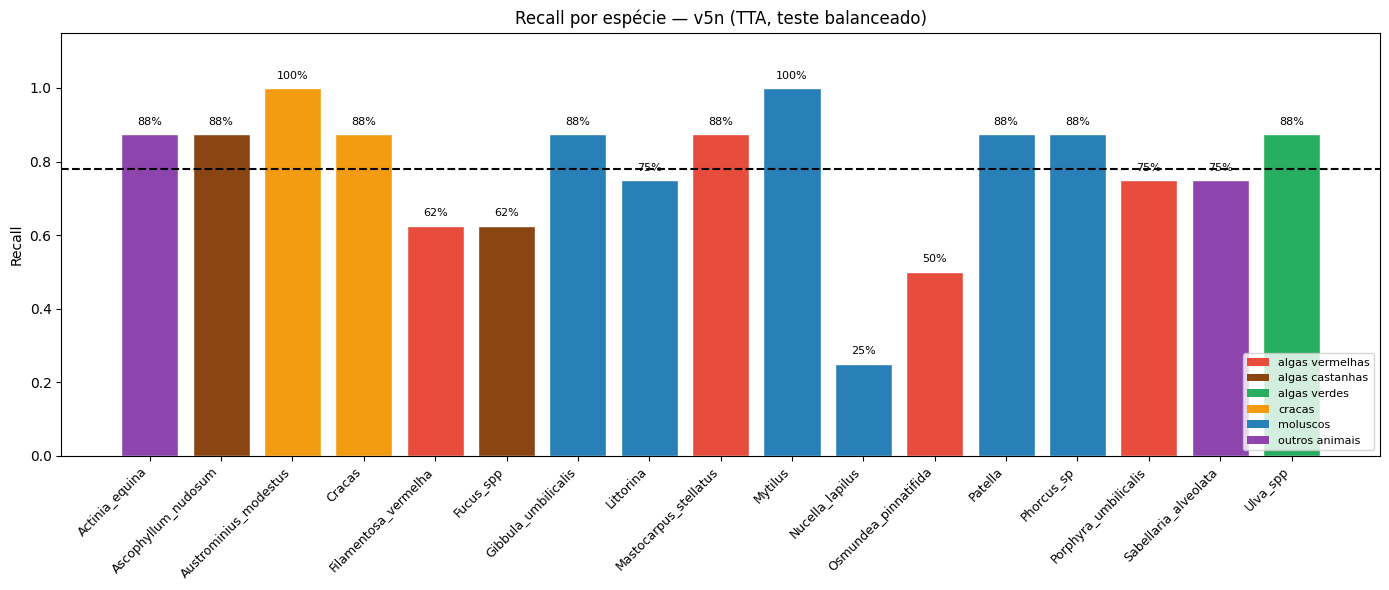


Recall por espécie (pior → melhor):
  Nucella_lapilus                     25% █████
  Osmundea_pinnatifida                50% ██████████
  Filamentosa_vermelha                62% ████████████ ⚠️ dados insuficientes
  Fucus_spp                           62% ████████████
  Littorina                           75% ███████████████
  Porphyra_umbilicalis                75% ███████████████
  Sabellaria_alveolata                75% ███████████████
  Actinia_equina                      88% █████████████████ ⚠️ dados insuficientes
  Ascophyllum_nudosum                 88% █████████████████
  Cracas                              88% █████████████████
  Gibbula_umbilicalis                 88% █████████████████
  Mastocarpus_stellatus               88% █████████████████
  Patella                             88% █████████████████
  Phorcus_sp                          88% █████████████████
  Ulva_spp                            88% █████████████████
  Austrominius_modestus               100% █████████

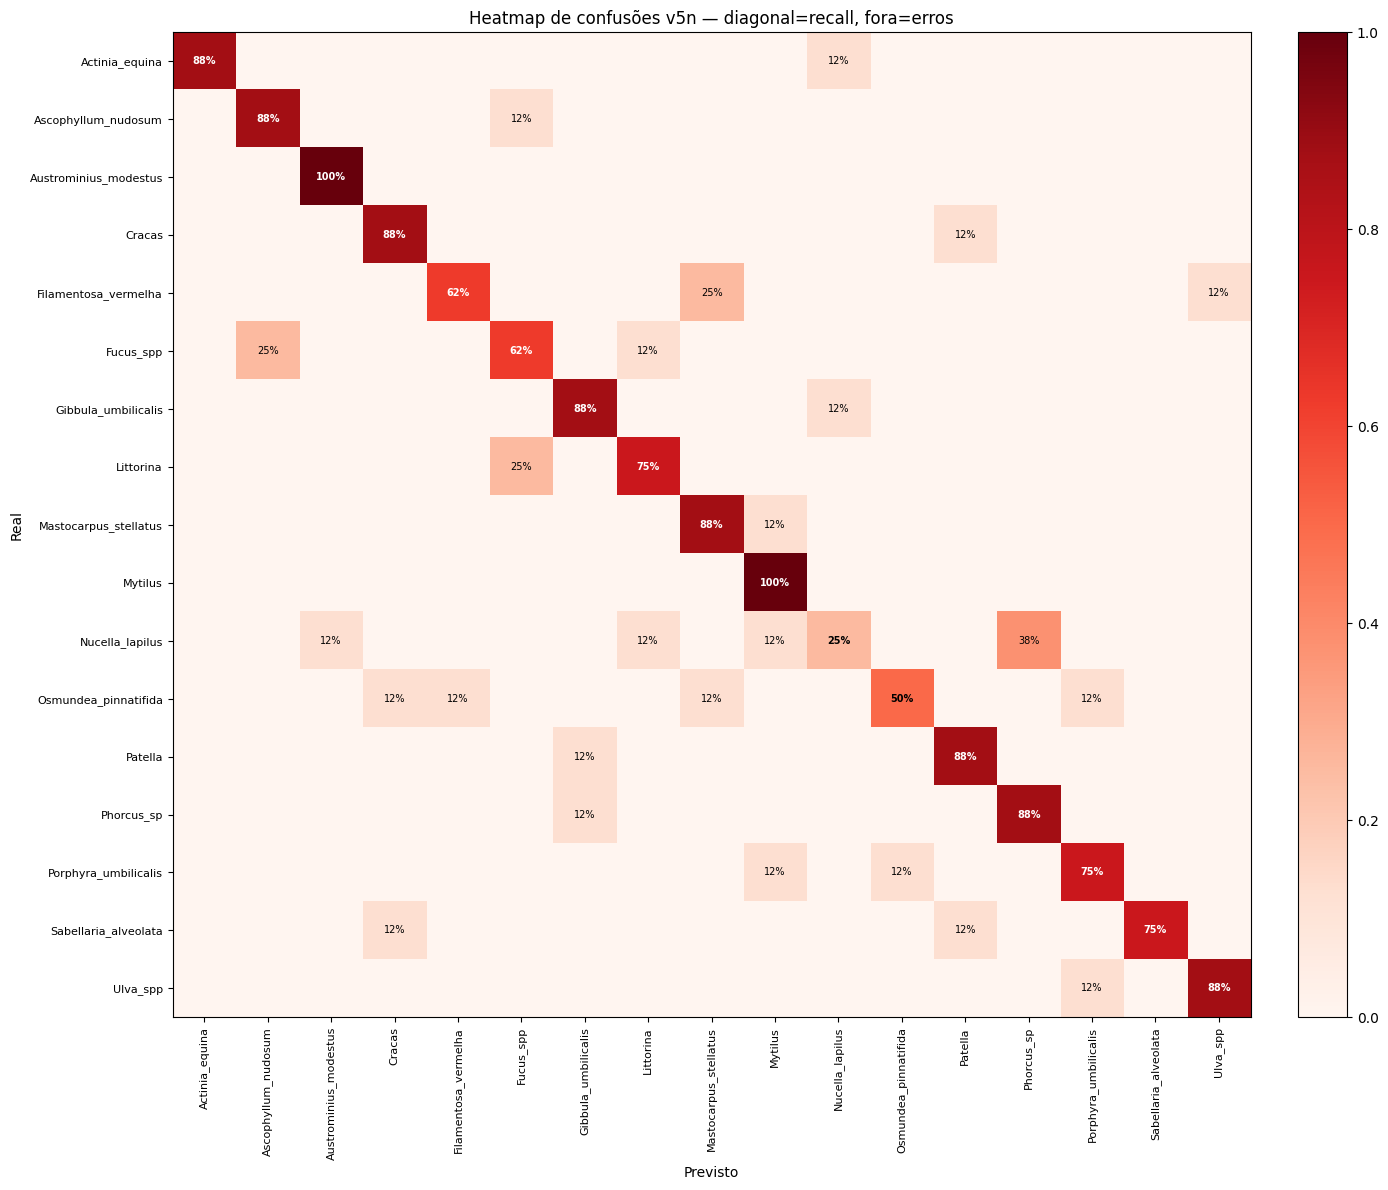


  N Real                           Previsto                        Mesmo grupo?
--------------------------------------------------------------------------------
  3  Nucella_lapilus                Phorcus_sp                             ✅ sim
  2  Littorina                      Fucus_spp                              ❌ não
  2  Fucus_spp                      Ascophyllum_nudosum                    ✅ sim
  2  Filamentosa_vermelha           Mastocarpus_stellatus                  ✅ sim
  1  Ulva_spp                       Porphyra_umbilicalis                   ❌ não
  1  Sabellaria_alveolata           Patella                                ❌ não
  1  Sabellaria_alveolata           Cracas                                 ❌ não
  1  Porphyra_umbilicalis           Osmundea_pinnatifida                   ✅ sim
  1  Porphyra_umbilicalis           Mytilus                                ❌ não
  1  Phorcus_sp                     Gibbula_umbilicalis                    ✅ sim
  1  Patella                

In [12]:
recalls = recall_score(labels_idx, preds_idx,
                       labels=list(range(n_cls_plot)),
                       average=None, zero_division=0)
cores = [grupo_cores.get(especie_para_grupo.get(cls,""), "#95a5a6")
         for cls in sorted_classes]

# Gráfico recall por espécie
fig, ax = plt.subplots(figsize=(14,6))
bars = ax.bar(sorted_classes, recalls, color=cores, edgecolor="white")
ax.set_ylim(0, 1.15); ax.set_ylabel("Recall")
ax.set_title("Recall por espécie — v5n (TTA, teste balanceado)")
ax.axhline(y=np.mean(recalls), color="black", linestyle="--",
           label=f"Média={np.mean(recalls):.2f}")
ax.set_xticks(range(len(sorted_classes)))
ax.set_xticklabels(sorted_classes, rotation=45, ha="right", fontsize=9)
for bar, val in zip(bars, recalls):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{val:.0%}", ha="center", va="bottom", fontsize=8)
legend_elements = [Patch(facecolor=cor, label=g.replace("_"," "))
                   for g, cor in grupo_cores.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

print("\nRecall por espécie (pior → melhor):")
for esp, rec in sorted(zip(sorted_classes, recalls), key=lambda x: x[1]):
    barra = "█" * int(rec * 20)
    flag  = " ⚠️ dados insuficientes" if esp in CLASSES_INSUFICIENTES else ""
    print(f"  {esp:<35} {rec:.0%} {barra}{flag}")

# Heatmap
cm = confusion_matrix(labels_idx, preds_idx, labels=list(range(n_cls_plot)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(14,12))
im = ax.imshow(cm_norm, cmap="Reds", aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(n_cls_plot)); ax.set_yticks(range(n_cls_plot))
ax.set_xticklabels(sorted_classes, rotation=90, fontsize=8)
ax.set_yticklabels(sorted_classes, fontsize=8)
ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
ax.set_title("Heatmap de confusões v5n — diagonal=recall, fora=erros")
for i in range(n_cls_plot):
    for j in range(n_cls_plot):
        if cm[i,j] > 0:
            cor_t = "white" if cm_norm[i,j] > 0.5 else "black"
            ax.text(j, i, f"{cm_norm[i,j]:.0%}", ha="center", va="center",
                    fontsize=7, color=cor_t, fontweight="bold" if i==j else "normal")
plt.tight_layout(); plt.show()

# Top-20 confusões
confusions_det = []
for i in range(n_cls_plot):
    for j in range(n_cls_plot):
        if i != j and cm[i,j] > 0:
            real = sorted_classes[i]; prev = sorted_classes[j]
            gr = especie_para_grupo.get(real,"?"); gp = especie_para_grupo.get(prev,"?")
            confusions_det.append((cm[i,j], real, prev, gr, gp, gr==gp))
confusions_det.sort(reverse=True)

print(f"\n{'N':>3} {'Real':<30} {'Previsto':<30} {'Mesmo grupo?':>13}")
print("-"*80)
for n, real, prev, gr, gp, mesmo in confusions_det[:20]:
    print(f"{n:>3}  {real:<30} {prev:<30} {'✅ sim' if mesmo else '❌ não':>13}")

# Por espécie problemática
print(f"\n{'='*65}")
print("CONFUSÕES POR ESPÉCIE PROBLEMÁTICA (recall < 70%)")
print(f"{'='*65}")
for i, (cls, rec) in enumerate(zip(sorted_classes, recalls)):
    if rec >= 0.70: continue
    print(f"\n{cls} (recall={rec:.0%}, grupo={especie_para_grupo.get(cls,'?')})"
          + (" ⚠️ dados insuficientes" if cls in CLASSES_INSUFICIENTES else "") + ":")
    erros = [(cm[i,j], sorted_classes[j]) for j in range(n_cls_plot) if i!=j and cm[i,j]>0]
    erros.sort(reverse=True)
    for n_err, prev in erros:
        gp = especie_para_grupo.get(prev,"?")
        mesmo = "mesmo grupo" if gp==especie_para_grupo.get(cls) else "grupo diferente ⚠️"
        print(f"  → {prev:<35} {n_err}x ({n_err/max(cm[i].sum(),1):.0%}) [{mesmo}]")

# Erros inter vs intra
erros_inter = sum(n for n,_,_,_,_,mesmo in confusions_det if not mesmo)
erros_intra = sum(n for n,_,_,_,_,mesmo in confusions_det if mesmo)
tot = erros_inter + erros_intra
if tot > 0:
    print(f"\n{'='*65}")
    print("ERROS: ENTRE GRUPOS vs DENTRO DO MESMO GRUPO")
    print(f"{'='*65}")
    print(f"  Inter-grupo (falha nível 1): {erros_inter} ({erros_inter/tot*100:.1f}%)")
    print(f"  Intra-grupo (falha esp. L2): {erros_intra} ({erros_intra/tot*100:.1f}%)")

# Confiança média por espécie
conf_c = defaultdict(list); conf_e = defaultdict(list)
for t, p, c in zip(all_true, all_pred, all_conf):
    if t==p: conf_c[t].append(c)
    else:    conf_e[t].append(c)

print(f"\n{'Espécie':<35} {'Conf. correcto':>15} {'Conf. errado':>13} {'Recall':>8}")
print("-"*75)
for cls in sorted_classes:
    rec = recalls[cls_to_idx[cls]]
    cc  = f"{np.mean(conf_c[cls]):.2f}" if conf_c[cls] else "  —  "
    ce  = f"{np.mean(conf_e[cls]):.2f}" if conf_e[cls] else "  —  "
    flag = " ⚠️" if cls in CLASSES_INSUFICIENTES else ""
    print(f"{cls:<35} {cc:>15} {ce:>13} {rec:>7.0%}{flag}")

## 12. Métricas finais — 17 classes

Resultados finais reportados para todas as 17 classes, com e sem limiar de confiança.

> **Nota:** *Actinia equina* e *Filamentosa vermelha* têm apenas ~9 crops de teste, provenientes exclusivamente do dataset FCUP — os seus valores individuais de recall têm alta variância dado o tamanho reduzido da amostra.

In [13]:
bal_17   = balanced_accuracy_score(labels_idx, preds_idx)
kap_17   = cohen_kappa_score(labels_idx, preds_idx)
mcc_17   = matthews_corrcoef(labels_idx, preds_idx)
_, ci_lo_17, ci_hi_17 = bootstrap_ci(labels_idx, preds_idx, BOOTSTRAP_N)

# Com threshold
true_t17, pred_t17 = [], []
n_rej_17 = 0
for t, p, c in zip(all_true, all_pred, all_conf):
    if c >= THRESHOLD_OPTIMO: true_t17.append(t); pred_t17.append(p)
    else: n_rej_17 += 1
bal_t17   = balanced_accuracy_score(true_t17, pred_t17)
kap_t17   = cohen_kappa_score(true_t17, pred_t17)
mcc_t17   = matthews_corrcoef(true_t17, pred_t17)
_, ci_lo_t17, ci_hi_t17 = bootstrap_ci(
    [cls_to_idx[t] for t in true_t17],
    [cls_to_idx.get(p,-1) for p in pred_t17], BOOTSTRAP_N)

print(f"\n{'='*65}")
print("MÉTRICAS FINAIS — 17 Classes")
print(f"{'='*65}")
print(f"\n{'Métrica':<35} {'Sem threshold':>14} {'Com threshold':>14}")
print("-"*65)
print(f"{'Balanced Accuracy':<35} {bal_17:>14.4f} {bal_t17:>14.4f}")
print(f"{'IC 95% (bootstrap)':<35} [{ci_lo_17:.3f},{ci_hi_17:.3f}]   [{ci_lo_t17:.3f},{ci_hi_t17:.3f}]")
print(f"{'Cohen Kappa':<35} {kap_17:>14.4f} {kap_t17:>14.4f}")
print(f"{'MCC':<35} {mcc_17:>14.4f} {mcc_t17:>14.4f}")
print(f"{'% Rejeitados':<35} {'0.0%':>14} {n_rej_17/len(all_true)*100:>13.1f}%")
print(f"\nNota: Actinia_equina e Filamentosa_vermelha têm ~9 crops de teste")
print(f"      (apenas dataset FCUP) — recall individual com alta variância.")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics


MÉTRICAS FINAIS — 17 Classes

Métrica                              Sem threshold  Com threshold
-----------------------------------------------------------------
Balanced Accuracy                           0.7794         0.8380
IC 95% (bootstrap)                  [0.710,0.841]   [0.766,0.908]
Cohen Kappa                                 0.7656         0.8257
MCC                                         0.7669         0.8269
% Rejeitados                                  0.0%          19.1%

Nota: Actinia_equina e Filamentosa_vermelha têm ~9 crops de teste
      (apenas dataset FCUP) — recall individual com alta variância.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics

## 13. Guardar modelos no Kaggle

Modelos guardados antes das análises finais para evitar perda em caso de falha de sessão.

In [14]:
OUT_DIR = "/kaggle/working/estagio-modelos-hierarquico-v5n"
os.makedirs(OUT_DIR, exist_ok=True)

shutil.copy(BEST_L1, os.path.join(OUT_DIR, "best_level1.pth"))
for grupo in GRUPOS_COM_ESPECIALISTA:
    src = f"/kaggle/working/best_l2_{grupo}_v5n.pth"
    if os.path.exists(src):
        shutil.copy(src, os.path.join(OUT_DIR, f"best_l2_{grupo}.pth"))
        print(f"Guardado: best_l2_{grupo}.pth")
shutil.copy(SPLIT_JSON, os.path.join(OUT_DIR, "foto_split.json"))

meta_v5n = {
    "class_names_l1":  class_names_l1,
    "classes_l2":      classes_l2,
    "grupos":          GRUPOS,
    "threshold":       THRESHOLD_OPTIMO,
    "classes_unknown": CLASSES_UNKNOWN,
    "n_classes":       len(TODAS_CLASSES),
    "min_test_crops":  int(min_test),
    "resultados": {
        "bal":         bal_17,
        "ci":          [ci_lo_17, ci_hi_17],
        "kappa":       kap_17,
        "mcc":         mcc_17,
        "bal_thresh":  bal_t17,
        "kappa_thresh": kap_t17,
        "mcc_thresh":  mcc_t17,
        "ci_thresh":   [ci_lo_t17, ci_hi_t17],
        "pct_rejeitados": n_rej_17/len(all_true)*100,
    },
    "metodologia": {
        "arquitectura":     "EfficientNet-B0",
        "split":            "por fotografia 70/15/15",
        "cap_por_foto":     MAX_CROPS_POR_FOTO,
        "nivel1_loss":      "CrossEntropy (sem class weights)",
        "nivel2_loss":      "Focal Loss gamma=0.5 com class weights",
        "scheduler":        "CosineAnnealingWarmRestarts",
        "mixup":            "só na fase 2",
        "lr_fase2":         "1e-4",
        "tta_passes":       len(tta_transforms),
        "oversample":       "adaptativo por classe",
        "early_stopping":   "val_acc",
        "threshold_em":     "validação",
        "bootstrap_n":      BOOTSTRAP_N,
    }
}
with open(os.path.join(OUT_DIR, "hierarquico_meta.json"), "w") as f:
    json.dump(meta_v5n, f, indent=2)

with open(os.path.join(OUT_DIR, "dataset-metadata.json"), "w") as f:
    json.dump({"title": "estagio-modelos-hierarquico-v5n",
               "id":    "catarinaabrantes/estagio-modelos-hierarquico-v5n",
               "licenses": [{"name": "CC0-1.0"}]}, f)

r = subprocess.run(["kaggle","datasets","create","-p", OUT_DIR],
                   capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    r2 = subprocess.run(["kaggle","datasets","version","-p", OUT_DIR,
                         "-m","v5n — lr=1e-4 fase 2"],
                        capture_output=True, text=True)
    print(r2.stdout)
    if r2.returncode != 0: print("ERRO:", r2.stderr)

print("\n✅ Dataset estagio-modelos-hierarquico-v5n guardado!")

Guardado: best_l2_algas_vermelhas.pth
Guardado: best_l2_algas_castanhas.pth
Guardado: best_l2_cracas.pth
Guardado: best_l2_moluscos.pth
Guardado: best_l2_outros_animais.pth
Starting upload for file foto_split.json
Upload successful: foto_split.json (934KB)
Starting upload for file best_l2_algas_vermelhas.pth
Upload successful: best_l2_algas_vermelhas.pth (16MB)
Starting upload for file best_level1.pth
Upload successful: best_level1.pth (16MB)
Starting upload for file best_l2_algas_castanhas.pth
Upload successful: best_l2_algas_castanhas.pth (16MB)
Starting upload for file best_l2_cracas.pth
Upload successful: best_l2_cracas.pth (16MB)
Starting upload for file best_l2_moluscos.pth
Upload successful: best_l2_moluscos.pth (16MB)
Starting upload for file best_l2_outros_animais.pth
Upload successful: best_l2_outros_animais.pth (16MB)
Starting upload for file hierarquico_meta.json
Upload successful: hierarquico_meta.json (2KB)
Your private Dataset is being created. Please check progress at h

## 14. Análise de correlação: número de fotografias de treino vs recall

Análise da relação entre a quantidade de dados de treino por espécie e o recall obtido. Correlação de Spearman (mais robusta para amostras pequenas e distribuições não-normais).

CORRELAÇÃO: Nº FOTOGRAFIAS DE TREINO vs RECALL

Espécie                             Fotos treino   Recall
---------------------------------------------------------
  Actinia_equina                              41     88%
  Ascophyllum_nudosum                         33     88%
  Austrominius_modestus                       27    100%
  Cracas                                     463     88%
  Filamentosa_vermelha                        23     62%
  Fucus_spp                                   70     62%
  Gibbula_umbilicalis                        165     88%
  Littorina                                   19     75%
  Mastocarpus_stellatus                       35     88%
  Mytilus                                    346    100%
  Nucella_lapilus                             60     25%
  Osmundea_pinnatifida                        41     50%
  Patella                                    430     88%
  Phorcus_sp                                 169     88%
  Porphyra_umbilicalis                

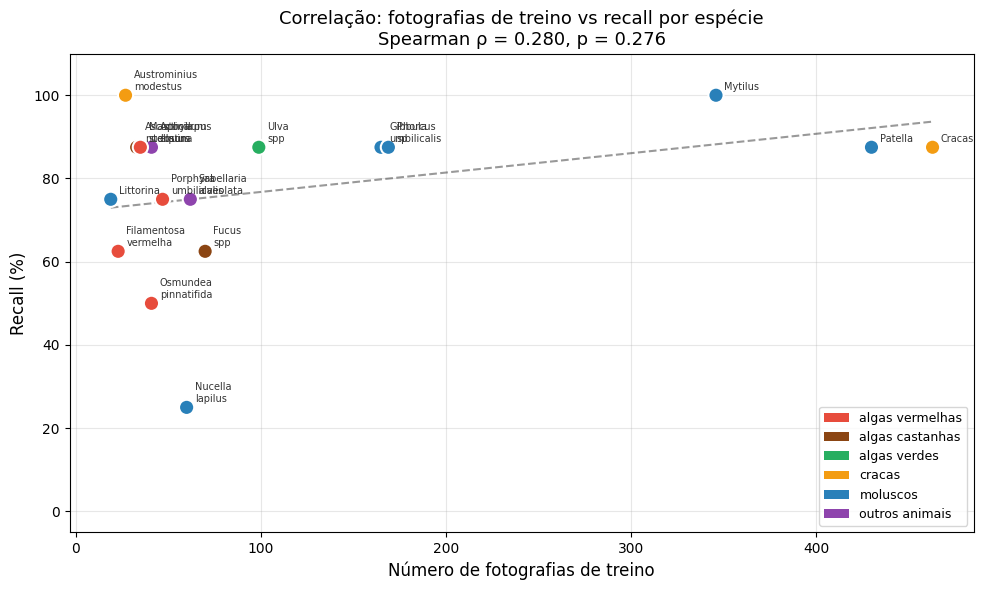


Nota: correlação calculada por espécie (n=17 pontos).
Espécies com <50 fotografias de treino são as mais problemáticas.


In [15]:
print("="*65)
print("CORRELAÇÃO: Nº FOTOGRAFIAS DE TREINO vs RECALL")
print("="*65)

# Contar fotografias de treino por espécie (não crops — fotografias únicas)
n_fotos_treino = {}
for cls in TODAS_CLASSES:
    fotos = [fk for fk, info in fotos_por_classe[cls].items()
             if foto_split_map.get(fk, {}).get(cls) == "train"]
    n_fotos_treino[cls] = len(fotos)

# Recall por espécie no teste balanceado
recalls_esp = recall_score(labels_idx, preds_idx,
                           labels=list(range(n_cls_plot)),
                           average=None, zero_division=0)

# Tabela
print(f"\n{'Espécie':<35} {'Fotos treino':>12} {'Recall':>8}")
print("-"*57)
fotos_list, recall_list = [], []
for cls, rec in zip(sorted_classes, recalls_esp):
    n = n_fotos_treino.get(cls, 0)
    fotos_list.append(n)
    recall_list.append(rec)
    print(f"  {cls:<33} {n:>12} {rec:>7.0%}")

# Correlação de Spearman (mais robusta para dados pequenos e não-normais)
rho, pval = stats.spearmanr(fotos_list, recall_list)
print(f"\nCorrelação de Spearman: ρ = {rho:.3f}  (p = {pval:.3f})")
if pval < 0.05:
    print("→ Correlação estatisticamente significativa (p < 0.05)")
else:
    print("→ Correlação não significativa (p ≥ 0.05) — amostra pequena")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
cores_grupo = [grupo_cores.get(especie_para_grupo.get(cls, ""), "#95a5a6")
               for cls in sorted_classes]
scatter = ax.scatter(fotos_list, [r*100 for r in recall_list],
                     c=cores_grupo, s=120, edgecolors="white", linewidth=1.5, zorder=3)

# Labels
for cls, n, rec in zip(sorted_classes, fotos_list, recall_list):
    ax.annotate(cls.replace("_", "\n"), (n, rec*100),
                textcoords="offset points", xytext=(6, 4), fontsize=7, color="#333333")

# Linha de tendência
z = np.polyfit(fotos_list, [r*100 for r in recall_list], 1)
p = np.poly1d(z)
x_line = np.linspace(min(fotos_list), max(fotos_list), 100)
ax.plot(x_line, p(x_line), "k--", alpha=0.4, linewidth=1.5, label="Tendência")

ax.set_xlabel("Número de fotografias de treino", fontsize=12)
ax.set_ylabel("Recall (%)", fontsize=12)
ax.set_title(f"Correlação: fotografias de treino vs recall por espécie\n"
             f"Spearman ρ = {rho:.3f}, p = {pval:.3f}", fontsize=13)
ax.set_ylim(-5, 110)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

legend_elements = [Patch(facecolor=cor, label=g.replace("_", " "))
                   for g, cor in grupo_cores.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print("\nNota: correlação calculada por espécie (n=17 pontos).")
print("Espécies com <50 fotografias de treino são as mais problemáticas.")

## 14b. Teste com espécies desconhecidas

Validação do mecanismo de rejeição por limiar de confiança. As 7 espécies excluídas do modelo por dados insuficientes são apresentadas ao pipeline — espera-se que sejam rejeitadas (confiança < 0,60) por serem classes não vistas durante o treino.

In [16]:
print(f"\nThreshold: {THRESHOLD_OPTIMO:.2f}\n")
for cls_unk in CLASSES_UNKNOWN:
    unk_dir = os.path.join(BASE_CROPS_UNK, cls_unk)
    if not os.path.exists(unk_dir) or len(os.listdir(unk_dir)) == 0:
        print(f"  {cls_unk}: sem crops"); continue
    imgs_pil = [Image.open(os.path.join(unk_dir, f)).convert("RGB")
                for f in os.listdir(unk_dir)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
    _, confs_unk = hierarquical_predict_tta(
        imgs_pil, model_l1, models_l2, classes_l2,
        class_names_l1, GRUPOS, device, tta_transforms)
    n_total = len(confs_unk)
    n_rej   = sum(1 for c in confs_unk if c < THRESHOLD_OPTIMO)
    pct_rej = n_rej / n_total * 100
    print(f"  {cls_unk:<35} n={n_total:>4} | rejeit.={n_rej:>3} ({pct_rej:.0f}%) | conf_média={np.mean(confs_unk):.2f}")


Threshold: 0.60

  Chondracantus_acicularis            n=  71 | rejeit.= 18 (25%) | conf_média=0.71
  Catenella_caespitosa                n= 105 | rejeit.= 34 (32%) | conf_média=0.69
  Caulacanthus_ustulatus              n=  79 | rejeit.= 22 (28%) | conf_média=0.69
  Fucus_vesiculosus                   n=  79 | rejeit.=  5 (6%) | conf_média=0.80
  Chondrus_crispus                    n=  18 | rejeit.=  4 (22%) | conf_média=0.75
  Hildenbrandia                       n=  24 | rejeit.= 10 (42%) | conf_média=0.69
  chthamallus                         n=  18 | rejeit.=  3 (17%) | conf_média=0.82


## 15. Resumo final completo

In [17]:
print(f"\n{'='*75}")
print("RESUMO FINAL — Pipeline Hierárquico v5n")
print(f"{'='*75}")
print(f"EfficientNet-B0 | Split 70/15/15 | Cap {MAX_CROPS_POR_FOTO} crops/foto")
print(f"Nível 1: CrossEntropy sem class weights | Especialistas: Focal Loss gamma=0.5")
print(f"Mixup (fase 2) + Cosine Annealing + TTA (5 passes)")
print(f"Oversample adaptativo | Patience={EARLY_STOP_PATIENCE}")
print(f"Threshold: {THRESHOLD_OPTIMO:.2f} (determinado na validação)")
print(f"Bootstrap IC 95% ({BOOTSTRAP_N} iterações)")
print()
print(f"{'Métrica':<35} {'Sem threshold':>14} {'Com threshold':>14}")
print("-"*65)
print(f"{'Balanced Accuracy':<35} {bal_17:>14.4f} {bal_t17:>14.4f}")
print(f"{'IC 95%':<35} [{ci_lo_17:.3f},{ci_hi_17:.3f}]   [{ci_lo_t17:.3f},{ci_hi_t17:.3f}]")
print(f"{'Cohen Kappa':<35} {kap_17:>14.4f} {kap_t17:>14.4f}")
print(f"{'MCC':<35} {mcc_17:>14.4f} {mcc_t17:>14.4f}")
print(f"{'% Rejeitados':<35} {'0.0%':>14} {n_rej_17/len(all_true)*100:>13.1f}%")
print()
print(f"{'='*75}")
print(f"{'Modelo':<52} {'Bal. Acc.':>10}")
print("-"*65)
print(f"{'Flat v1 (split foto, sem thresh.)':<52} {'0.6797':>10}")
print(f"{'Flat v1 (split foto, com thresh.)':<52} {'0.7327':>10}")
print(f"{'Hierárquico v5c (B0, sem thresh.)':<52} {'0.7059':>10}")
print(f"{'Hierárquico v5c (B0, com thresh.)':<52} {'0.7388':>10}")
print(f"{'Hierárquico v5g (B3, sem thresh.)':<52} {'0.6471':>10}")
print(f"{'Hierárquico v5g (B3, com thresh.)':<52} {'0.7078':>10}")
print(f"{'Hierárquico v5j (B0, sem thresh.)':<52} {'0.6250':>10}")
print(f"{'Hierárquico v5j (B0, com thresh.)':<52} {'0.6373':>10}")
print(f"{'Hierárquico v5l (B0, sem thresh.)':<52} {'0.6912':>10}")
print(f"{'Hierárquico v5l (B0, com thresh.)':<52} {'0.7648':>10}")
print(f"{'Hierárquico v5m (B0, sem thresh.)':<52} {'0.6471':>10}")
print(f"{'Hierárquico v5m (B0, com thresh.)':<52} {'0.6966':>10}")
print(f"{'Hierárquico v5n (B0, sem thresh.)':<52} {bal_17:>10.4f}")
print(f"{'Hierárquico v5n (B0, com thresh.)':<52} {bal_t17:>10.4f}")
print("="*65)


RESUMO FINAL — Pipeline Hierárquico v5n
EfficientNet-B0 | Split 70/15/15 | Cap 15 crops/foto
Nível 1: Focal Loss gamma=0.5 com class weights | Especialistas: Focal Loss gamma=0.5
Mixup (fase 2) + Cosine Annealing + TTA (5 passes)
Oversample adaptativo | Patience=10
Threshold: 0.60 (determinado na validação)
Bootstrap IC 95% (1000 iterações)

Métrica                              Sem threshold  Com threshold
-----------------------------------------------------------------
Balanced Accuracy                           0.7794         0.8380
IC 95%                              [0.710,0.841]   [0.766,0.908]
Cohen Kappa                                 0.7656         0.8257
MCC                                         0.7669         0.8269
% Rejeitados                                  0.0%          19.1%

Modelo                                                Bal. Acc.
-----------------------------------------------------------------
Flat v1 (split foto, sem thresh.)                        0.679

## 16. Demo de inferência — corre de forma independente

Esta secção carrega os modelos guardados a partir do dataset
`estagio-modelos-hierarquico-v5n` e permite classificar novos crops
sem necessidade de re-treinar. Pode ser executada independentemente
do resto do notebook.

In [ ]:
# Criar test_bal em working (o input não tem esta pasta)
BASE_CROPS_TEST_BAL_DEMO = "/kaggle/working/test_bal"

if not os.path.exists(BASE_CROPS_TEST_BAL_DEMO):
    os.makedirs(BASE_CROPS_TEST_BAL_DEMO, exist_ok=True)

    n_test_por_classe = {}
    for cls in TODAS_CLASSES:
        p = os.path.join(BASE_CROPS_TEST, cls)
        n_test_por_classe[cls] = len(os.listdir(p)) if os.path.exists(p) else 0

    min_test_demo = min(n_test_por_classe.values())
    print(f"A criar test_bal: {min_test_demo} crops por classe")

    for cls in TODAS_CLASSES:
        src = os.path.join(BASE_CROPS_TEST, cls)
        if not os.path.exists(src): continue
        dst = os.path.join(BASE_CROPS_TEST_BAL_DEMO, cls)
        os.makedirs(dst, exist_ok=True)
        imgs = os.listdir(src)
        for img in random.sample(imgs, min(min_test_demo, len(imgs))):
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))

    print(f"✓ test_bal criado: {min_test_demo} × {len(TODAS_CLASSES)} = {min_test_demo*len(TODAS_CLASSES)} crops")
else:
    print("test_bal já existe")

# Carregar metadados
MODELS_INPUT = "/kaggle/input/datasets/catarinaabrantes/estagio-modelos-hierarquico-v5n"

with open(os.path.join(MODELS_INPUT, "hierarquico_meta.json")) as f:
    meta = json.load(f)

class_names_l1_demo = meta["class_names_l1"]
classes_l2_demo     = meta["classes_l2"]
THRESHOLD           = meta["threshold"]
print(f"Threshold: {THRESHOLD:.2f}")
print(f"Classes nível 1: {class_names_l1_demo}")

# Carregar modelo nível 1
model_l1_demo = build_efficientnet_b0(len(class_names_l1_demo), device)
model_l1_demo.load_state_dict(torch.load(
    os.path.join(MODELS_INPUT, "best_level1.pth"), map_location=device))
model_l1_demo.eval()
print("✓ Modelo nível 1 carregado")

# Carregar especialistas
models_l2_demo = {}
GRUPOS_COM_ESPECIALISTA_DEMO = {k: v for k, v in GRUPOS.items() if len(v) > 1}
for grupo in GRUPOS_COM_ESPECIALISTA_DEMO:
    path = os.path.join(MODELS_INPUT, f"best_l2_{grupo}.pth")
    if not os.path.exists(path):
        print(f"  ⚠ Modelo {grupo} não encontrado"); continue
    m = build_efficientnet_b0(len(classes_l2_demo[grupo]), device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    models_l2_demo[grupo] = m
    print(f"✓ Especialista {grupo} carregado ({len(classes_l2_demo[grupo])} classes)")

In [ ]:
def classificar_crop(img_pil, threshold=None):
    """
    Classifica um crop de imagem usando o pipeline hierárquico com TTA.

    Args:
        img_pil: imagem PIL (RGB)
        threshold: confiança mínima (None = usar threshold do modelo)

    Returns:
        dict com especie, grupo, confianca, rejeitado, probs_grupo, probs_especie, top3
    """
    if threshold is None:
        threshold = THRESHOLD

    # Nível 1 — classificar grupo com TTA
    probs_l1_tta = []
    with torch.no_grad():
        for t in tta_transforms:
            tensor = t(img_pil).unsqueeze(0).to(device)
            probs_l1_tta.append(F.softmax(model_l1_demo(tensor), dim=1))
    probs_l1   = torch.stack(probs_l1_tta).mean(0)[0].cpu().numpy()
    grupo_idx  = probs_l1.argmax()
    grupo_nome = class_names_l1_demo[grupo_idx]
    probs_grupo = {class_names_l1_demo[i]: float(probs_l1[i]) for i in range(len(class_names_l1_demo))}

    especies_do_grupo = GRUPOS.get(grupo_nome, [])

    # Nível 2 — classificar espécie dentro do grupo
    if len(especies_do_grupo) == 1:
        especie   = especies_do_grupo[0]
        confianca = float(probs_l1[grupo_idx])
        probs_esp = {especie: confianca}
    elif grupo_nome in models_l2_demo:
        probs_l2_tta = []
        with torch.no_grad():
            for t in tta_transforms:
                tensor = t(img_pil).unsqueeze(0).to(device)
                probs_l2_tta.append(F.softmax(models_l2_demo[grupo_nome](tensor), dim=1))
        probs_l2  = torch.stack(probs_l2_tta).mean(0)[0].cpu().numpy()
        esp_idx   = probs_l2.argmax()
        especie   = classes_l2_demo[grupo_nome][esp_idx]
        confianca = float(probs_l2[esp_idx])
        probs_esp = {classes_l2_demo[grupo_nome][i]: float(probs_l2[i])
                     for i in range(len(classes_l2_demo[grupo_nome]))}
    else:
        especie   = grupo_nome
        confianca = float(probs_l1[grupo_idx])
        probs_esp = {grupo_nome: confianca}

    rejeitado = confianca < threshold
    top3 = sorted(probs_esp.items(), key=lambda x: x[1], reverse=True)[:3]

    return {
        "especie":       especie if not rejeitado else "Desconhecida",
        "especie_raw":   especie,
        "grupo":         grupo_nome,
        "confianca":     confianca,
        "rejeitado":     rejeitado,
        "threshold":     threshold,
        "probs_grupo":   probs_grupo,
        "probs_especie": probs_esp,
        "top3":          top3,
    }

print("Função de inferência OK")

In [ ]:
def mostrar_resultado(img_pil, resultado, titulo="Classificação"):
    """Visualiza o crop e o resultado da classificação."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].imshow(img_pil)
    cor_grupo = grupo_cores.get(resultado["grupo"], "#95a5a6")
    axes[0].set_title(
        f"{'⚠ REJEITADO' if resultado['rejeitado'] else resultado['especie']}\n"
        f"Grupo: {resultado['grupo']} | Confiança: {resultado['confianca']:.1%}",
        color="red" if resultado["rejeitado"] else cor_grupo,
        fontsize=13, fontweight="bold"
    )
    axes[0].axis("off")

    probs    = resultado["probs_especie"]
    especies = list(probs.keys())
    valores  = list(probs.values())
    cores    = [cor_grupo] * len(especies)
    idx_max  = np.argmax(valores)

    bars = axes[1].barh(especies, valores, color=cores, edgecolor="white", alpha=0.7)
    bars[idx_max].set_alpha(1.0)
    bars[idx_max].set_edgecolor("black")
    axes[1].axvline(x=resultado["threshold"], color="red", linestyle="--",
                    label=f"Threshold={resultado['threshold']:.2f}", alpha=0.7)
    for bar, val in zip(bars, valores):
        axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f"{val:.1%}", va="center", fontsize=10)
    axes[1].set_xlim(0, 1.15)
    axes[1].set_xlabel("Probabilidade")
    axes[1].set_title(f"Probabilidades — {resultado['grupo']}")
    axes[1].legend()
    plt.suptitle(titulo, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"Resultado: {resultado['especie']}")
    print(f"Grupo:     {resultado['grupo']}")
    print(f"Confiança: {resultado['confianca']:.1%}")
    print(f"Rejeitado: {'Sim ⚠' if resultado['rejeitado'] else 'Não ✓'}")
    print(f"\nTop 3 candidatas:")
    for esp, prob in resultado["top3"]:
        print(f"  {esp:<35} {prob:.1%}")
    print(f"{'='*50}")

# ─── EXEMPLO DE USO ───────────────────────────────────────────
# Para classificar o teu próprio crop:
#
#   img = Image.open("/caminho/para/crop.jpg").convert("RGB")
#   resultado = classificar_crop(img)
#   mostrar_resultado(img, resultado)
#
# Exemplo com crop aleatório do dataset de teste:

cls_exemplo = random.choice(TODAS_CLASSES)
dir_exemplo  = os.path.join(BASE_CROPS_TEST, cls_exemplo)

if os.path.exists(dir_exemplo) and os.listdir(dir_exemplo):
    ficheiro    = random.choice(os.listdir(dir_exemplo))
    img_exemplo = Image.open(os.path.join(dir_exemplo, ficheiro)).convert("RGB")
    resultado_exemplo = classificar_crop(img_exemplo)
    mostrar_resultado(img_exemplo, resultado_exemplo,
                      titulo=f"Exemplo — Classe real: {cls_exemplo}")

### Avaliação completa no teste balanceado

In [ ]:
print("A avaliar pipeline com TTA no teste balanceado...")
all_true_demo, all_pred_demo, all_conf_demo = [], [], []

for cls_name in sorted(os.listdir(BASE_CROPS_TEST_BAL_DEMO)):
    cls_dir = os.path.join(BASE_CROPS_TEST_BAL_DEMO, cls_name)
    if not os.path.isdir(cls_dir): continue
    for img_file in os.listdir(cls_dir):
        img_pil = Image.open(os.path.join(cls_dir, img_file)).convert("RGB")
        res = classificar_crop(img_pil, threshold=0.0)
        all_true_demo.append(cls_name)
        all_pred_demo.append(res["especie_raw"])
        all_conf_demo.append(res["confianca"])

cls_to_idx_demo   = {c: i for i, c in enumerate(sorted(set(all_true_demo)))}
labels_idx_demo   = [cls_to_idx_demo[t] for t in all_true_demo]
preds_idx_demo    = [cls_to_idx_demo.get(p, -1) for p in all_pred_demo]
sorted_classes_demo = sorted(set(all_true_demo))
n_cls_demo        = len(sorted_classes_demo)

bal_demo = balanced_accuracy_score(labels_idx_demo, preds_idx_demo)
print(f"\nBalanced Accuracy (sem threshold): {bal_demo:.4f}")

In [ ]:
recalls_demo = recall_score(labels_idx_demo, preds_idx_demo,
                            labels=list(range(n_cls_demo)), average=None, zero_division=0)
cores_barras = [grupo_cores.get(especie_para_grupo.get(cls, ""), "#95a5a6")
                for cls in sorted_classes_demo]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(sorted_classes_demo, recalls_demo, color=cores_barras, edgecolor="white")
ax.set_ylim(0, 1.2)
ax.set_ylabel("Recall", fontsize=12)
ax.set_title("Recall por espécie — pipeline hierárquico v5n (TTA, teste balanceado)", fontsize=13)
ax.axhline(y=np.mean(recalls_demo), color="black", linestyle="--",
           label=f"Média = {np.mean(recalls_demo):.2f}")
ax.set_xticks(range(n_cls_demo))
ax.set_xticklabels(sorted_classes_demo, rotation=45, ha="right", fontsize=9)
for bar, val in zip(bars, recalls_demo):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.0%}", ha="center", va="bottom", fontsize=8)
legend_elements = [Patch(facecolor=cor, label=g.replace("_", " "))
                   for g, cor in grupo_cores.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
cm_demo = confusion_matrix(labels_idx_demo, preds_idx_demo, labels=list(range(n_cls_demo)))
cm_norm_demo = cm_demo.astype(float) / cm_demo.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
ConfusionMatrixDisplay(cm_demo, display_labels=sorted_classes_demo).plot(
    ax=axes[0], xticks_rotation=90, cmap="Purples", colorbar=False)
axes[0].set_title("Matriz de confusão — Contagens")
ConfusionMatrixDisplay(cm_norm_demo, display_labels=sorted_classes_demo).plot(
    ax=axes[1], xticks_rotation=90, cmap="Purples", colorbar=False)
axes[1].set_title("Matriz de confusão — Normalizada")
plt.tight_layout()
plt.show()

In [ ]:
print("A calcular threshold na validação...")
val_true_demo, val_pred_demo, val_conf_demo = [], [], []

for cls_name in sorted(os.listdir(BASE_CROPS_VAL)):
    cls_dir = os.path.join(BASE_CROPS_VAL, cls_name)
    if not os.path.isdir(cls_dir): continue
    for img_file in os.listdir(cls_dir):
        img_pil = Image.open(os.path.join(cls_dir, img_file)).convert("RGB")
        res = classificar_crop(img_pil, threshold=0.0)
        val_true_demo.append(cls_name)
        val_pred_demo.append(res["especie_raw"])
        val_conf_demo.append(res["confianca"])

thresholds = np.arange(0.30, 0.95, 0.05)
resultados_val_demo = []
for thresh in thresholds:
    true_f, pred_f, n_rej = [], [], 0
    for t, p, c in zip(val_true_demo, val_pred_demo, val_conf_demo):
        if c >= thresh: true_f.append(t); pred_f.append(p)
        else: n_rej += 1
    if not true_f: continue
    bal_v = balanced_accuracy_score(true_f, pred_f)
    pct   = n_rej / len(val_conf_demo) * 100
    resultados_val_demo.append((thresh, bal_v, pct))

melhor = max((r for r in resultados_val_demo if r[2] < 20.0), key=lambda r: r[1], default=None)
THRESHOLD_OPTIMO_DEMO = melhor[0] if melhor else 0.5
print(f"Threshold óptimo: {THRESHOLD_OPTIMO_DEMO:.2f}")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ts  = [r[0] for r in resultados_val_demo]
bs  = [r[1] for r in resultados_val_demo]
rjs = [r[2] for r in resultados_val_demo]
ax1.plot(ts, bs,  "b-o", label="Balanced acc (validação)")
ax2.plot(ts, rjs, "r--s", label="% Rejeitados")
ax1.axvline(x=THRESHOLD_OPTIMO_DEMO, color="green", linestyle="--",
            label=f"Threshold={THRESHOLD_OPTIMO_DEMO:.2f}")
ax1.set_xlabel("Threshold"); ax1.set_ylabel("Balanced accuracy", color="b")
ax2.set_ylabel("% Rejeitados", color="r")
ax1.set_ylim(0, 1); ax2.set_ylim(0, 100)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
lbls  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, lbls, loc="lower left")
plt.title("Threshold — determinado na validação")
plt.tight_layout()
plt.show()

In [ ]:
bal_17_demo = balanced_accuracy_score(labels_idx_demo, preds_idx_demo)
kap_17_demo = cohen_kappa_score(labels_idx_demo, preds_idx_demo)
mcc_17_demo = matthews_corrcoef(labels_idx_demo, preds_idx_demo)

true_t_demo, pred_t_demo, n_rej_t_demo = [], [], 0
for t, p, c in zip(all_true_demo, all_pred_demo, all_conf_demo):
    if c >= THRESHOLD_OPTIMO_DEMO: true_t_demo.append(t); pred_t_demo.append(p)
    else: n_rej_t_demo += 1
bal_t_demo = balanced_accuracy_score(true_t_demo, pred_t_demo)
kap_t_demo = cohen_kappa_score(true_t_demo, pred_t_demo)
mcc_t_demo = matthews_corrcoef(true_t_demo, pred_t_demo)

print(f"\n{'='*65}")
print("MÉTRICAS FINAIS — 17 Classes")
print(f"{'='*65}")
print(f"\n{'Métrica':<35} {'Sem threshold':>14} {'Com threshold':>14}")
print("-"*65)
print(f"{'Balanced Accuracy':<35} {bal_17_demo:>14.4f} {bal_t_demo:>14.4f}")
print(f"{'Cohen Kappa':<35} {kap_17_demo:>14.4f} {kap_t_demo:>14.4f}")
print(f"{'MCC':<35} {mcc_17_demo:>14.4f} {mcc_t_demo:>14.4f}")
print(f"{'% Rejeitados':<35} {'0.0%':>14} {n_rej_t_demo/len(all_true_demo)*100:>13.1f}%")

In [ ]:
confusions_det_demo = []
for i in range(n_cls_demo):
    for j in range(n_cls_demo):
        if i != j and cm_demo[i,j] > 0:
            real = sorted_classes_demo[i]; prev = sorted_classes_demo[j]
            gr = especie_para_grupo.get(real,"?"); gp = especie_para_grupo.get(prev,"?")
            confusions_det_demo.append((cm_demo[i,j], real, prev, gr, gp, gr==gp))
confusions_det_demo.sort(reverse=True)

erros_inter = sum(n for n,_,_,_,_,mesmo in confusions_det_demo if not mesmo)
erros_intra = sum(n for n,_,_,_,_,mesmo in confusions_det_demo if mesmo)
tot = erros_inter + erros_intra

print(f"  Inter-grupo (falha nível 1): {erros_inter} ({erros_inter/tot*100:.1f}%)")
print(f"  Intra-grupo (falha esp. L2): {erros_intra} ({erros_intra/tot*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie([erros_inter, erros_intra],
       labels=[f"Nível 1\n(inter-grupo)\n{erros_inter/tot*100:.1f}%",
               f"Nível 2\n(intra-grupo)\n{erros_intra/tot*100:.1f}%"],
       colors=["#e74c3c", "#3498db"],
       autopct="%1.1f%%", startangle=90,
       wedgeprops=dict(edgecolor="white", linewidth=2))
ax.set_title("Distribuição de erros por nível do pipeline", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def classificar_pasta(pasta, threshold=None):
    """
    Classifica todos os crops numa pasta e reporta resultados.
    Útil para integração com o segmentador.

    Args:
        pasta: caminho para pasta com imagens (jpg/png)
        threshold: confiança mínima (None = threshold do modelo)
    """
    if threshold is None:
        threshold = THRESHOLD

    resultados = []
    for fname in os.listdir(pasta):
        if not fname.lower().endswith((".jpg",".jpeg",".png")): continue
        img = Image.open(os.path.join(pasta, fname)).convert("RGB")
        res = classificar_crop(img, threshold=threshold)
        resultados.append({"ficheiro": fname, **res})

    n_total  = len(resultados)
    n_rejeit = sum(1 for r in resultados if r["rejeitado"])

    print(f"\n{'='*55}")
    print(f"Resultados para {pasta}")
    print(f"{'='*55}")
    print(f"Total: {n_total} | Aceites: {n_total-n_rejeit} | Rejeitados: {n_rejeit} ({n_rejeit/n_total*100:.1f}%)")
    print(f"\nEspécies identificadas:")
    from collections import Counter
    for esp, n in Counter(r["especie"] for r in resultados if not r["rejeitado"]).most_common():
        print(f"  {esp:<35} {n:>4} crops")

    return resultados

# Exemplo de uso:
# resultados = classificar_pasta("/caminho/para/crops")

### Como adaptar o modelo a novas espécies

1. Adicionar a nova espécie ao dicionário `GRUPOS` no notebook de treino
2. Preparar imagens em formato COCO (bounding boxes anotadas)
3. Re-treinar o especialista do grupo correspondente — não é necessário re-treinar o nível 1 se a espécie pertence a um grupo já existente
4. Se for um novo grupo biológico: adicionar ao `GRUPOS`, re-treinar o nível 1 e treinar o novo especialista
5. Actualizar `MODELS_INPUT` para os novos modelos — esta secção de inferência não precisa de outras alterações